# DIAGNOSTICO DEL CASO PRACTICO

## Atención Ambulatoria

In [29]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### Se automatizó la lectura y consolidación de datos 2024–2025 de la atención ambulatoria en un único dataset para facilitar el análisis

In [ ]:
##Lectura

import pandas as pd
import os

ruta_base = r"C:\Users\PROPIETARIO\Desktop\PROGRAMACIÓN\PRACTICANDO-PYTHON\PROYECTO CLINICA\atencion ambulatoria"

# ✅ Lee todos los archivos CSV de cada subcarpeta automáticamente
def leer_carpeta(ruta):
    archivos = [f for f in os.listdir(ruta) if f.endswith(".csv")]
    dfs = []
    for archivo in archivos:
        df = pd.read_csv(os.path.join(ruta, archivo), encoding="latin-1", sep=";")
        print(f"   📄 {archivo} — {len(df)} filas")
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

# Lee 2024
print("📂 Leyendo ambulatoria 2024...")
data_2024 = leer_carpeta(os.path.join(ruta_base, "ambulatoria 2024"))
print(f"✅ Total 2024: {len(data_2024)} filas\n")

# Lee 2025
print("📂 Leyendo ambulatoria 2025...")
data_2025 = leer_carpeta(os.path.join(ruta_base, "ambulatoria 2025"))
print(f"✅ Total 2025: {len(data_2025)} filas\n")

# Une todo en un solo DataFrame
data_total = pd.concat([data_2024, data_2025], ignore_index=True)
print(f"📊 TOTAL GENERAL: {len(data_total)} filas")


In [31]:

# ── Unirlos en uno solo ────────────────────────────────
print("\n")
print("=" * 60)
print("📋 DATA TOTAL (2024 + 2025)")
print("=" * 60)

data_2024["AÑO"] = 2024   # Agrega columna identificadora
data_2025["AÑO"] = 2025

data_total = pd.concat([data_2024, data_2025], ignore_index=True)

print(f"Filas totales: {data_total.shape[0]} | Columnas: {data_total.shape[1]}")
print(data_total.head(10))


# ── Ver detalles completos ─────────────────────────────
print("\n")
print("=" * 60)
print("🔍 DETALLES DE COLUMNAS")
print("=" * 60)
print(data_total.dtypes)         # Tipos de datos
print("\n")
print(data_total.describe())     # Estadísticas generales
print("\n")
print(f"Valores nulos:\n{data_total.isnull().sum()}")  # Nulos por columna



📋 DATA TOTAL (2024 + 2025)
Filas totales: 45606673 | Columnas: 16
   ï»¿"ANHO"  MES  UBIGEO DEPARTAMENTO      PROVINCIA  DISTRITO  \
0     2024.0    1   80902        CUSCO  LA CONVENCION  ECHARATE   
1     2024.0    1   80902        CUSCO  LA CONVENCION  ECHARATE   
2     2024.0    1   80902        CUSCO  LA CONVENCION  ECHARATE   
3     2024.0    1   80902        CUSCO  LA CONVENCION  ECHARATE   
4     2024.0    1   80902        CUSCO  LA CONVENCION  ECHARATE   
5     2024.0    1   80902        CUSCO  LA CONVENCION  ECHARATE   
6     2024.0    1   80902        CUSCO  LA CONVENCION  ECHARATE   
7     2024.0    1   80902        CUSCO  LA CONVENCION  ECHARATE   
8     2024.0    1   80902        CUSCO  LA CONVENCION  ECHARATE   
9     2024.0    1   80902        CUSCO  LA CONVENCION  ECHARATE   

              SECTOR CATEGORIA  CO_IPRESS RAZON_SOC SEXO EDAD DIAGNOSTICO  \
0  GOBIERNO REGIONAL       I-3       2425  ECHARATE    1   12       S90.3   
1  GOBIERNO REGIONAL       I-3       242

##### Analizamos cada variable

In [32]:
# ── Ver columnas ─────────────────────────────────────────
print("\n📋 COLUMNAS AMBULATORIA:")
for i, col in enumerate(data_total.columns, 1):
    print(f"  {i:>2}. {col}")

print(f"\n🔍 Ejemplo primeras 2 filas:")
print(data_total.head(2).to_string())


📋 COLUMNAS AMBULATORIA:
   1. ï»¿"ANHO"
   2. MES
   3. UBIGEO
   4. DEPARTAMENTO
   5. PROVINCIA
   6. DISTRITO
   7. SECTOR
   8. CATEGORIA
   9. CO_IPRESS
  10. RAZON_SOC
  11. SEXO
  12. EDAD
  13. DIAGNOSTICO
  14. NU_TOTAL_ATENDIDOS
  15. ANHO
  16. AÑO

🔍 Ejemplo primeras 2 filas:
   ï»¿"ANHO"  MES  UBIGEO DEPARTAMENTO      PROVINCIA  DISTRITO             SECTOR CATEGORIA  CO_IPRESS RAZON_SOC SEXO EDAD DIAGNOSTICO NU_TOTAL_ATENDIDOS  ANHO   AÑO
0     2024.0    1   80902        CUSCO  LA CONVENCION  ECHARATE  GOBIERNO REGIONAL       I-3       2425  ECHARATE    1   12       S90.3                  1   NaN  2024
1     2024.0    1   80902        CUSCO  LA CONVENCION  ECHARATE  GOBIERNO REGIONAL       I-3       2425  ECHARATE    1   12       T78.4                  1   NaN  2024


### DISTRICIÓN POR DISTRITOS

##### Se realizó una segmentación geográfica de los datos utilizando la clasificación de zonas de Lima (Norte, Sur, Centro, Este y Callao). Para ello, se definieron listas de distritos por zona y se implementó una función que asigna cada registro a su categoría correspondiente.

In [33]:
# ── Clasificación ────────────────────────────────────

lima_norte  = ["Ancón", "Carabayllo", "Comas", "Independencia",
               "Los Olivos", "Puente Piedra", "San Martín De Porres",
               "San Martin De Porres",          # sin tilde
               "Santa Rosa", "Ancón", "Ancon"]  # alias sin tilde

lima_sur    = ["Chorrillos", "Lurín", "Lurin", "Pachacamac", "Pucusana",
               "Punta Hermosa", "Punta Negra", "San Bartolo",
               "San Juan De Miraflores", "Santa María", "Santa Maria",
               "Santa Maria Del Mar",
               "Villa El Salvador",
               "Villa María Del Triunfo", "Villa Maria Del Triunfo"]

lima_centro = ["Barranco", "Breña", "Brena", "Jesús María", "Jesus Maria",
               "La Molina", "La Victoria", "Lima", "Lince",
               "Magdalena", "Magdalena Del Mar",
               "Miraflores", "Pueblo Libre",
               "Rímac", "Rimac",
               "San Borja", "San Isidro", "San Miguel",
               "Santiago De Surco", "Surco", "Surquillo"]

lima_este   = ["Ate", "Chaclacayo", "Cieneguilla", "El Agustino",
               "Lurigancho", "San Juan De Lurigancho", "San Luis", "Santa Anita"]

callao      = ["Bellavista", "Callao",
               "Carmen De La Legua-Reynoso",   # con guión
               "Carmen De La Legua Reynoso",   # sin guión
               "La Perla", "La Punta",
               "Mi Perú", "Mi Peru",
               "Ventanilla"]

def asignar_zona(distrito):
    if distrito in lima_norte:   return "Lima Norte"
    if distrito in lima_sur:     return "Lima Sur"
    if distrito in lima_centro:  return "Lima Centro"
    if distrito in lima_este:    return "Lima Este"
    if distrito in callao:       return "Callao"
    return "Fuera de Lima"

# ── Aplicar (str.title() convierte "SAN BORJA" → "San Borja") ─
data_total["ZONA_LIMA"] = data_total["DISTRITO"].str.strip().str.title().apply(asignar_zona)

# ── Verificar ─────────────────────────────────────────────────
print(data_total["ZONA_LIMA"].value_counts())
print(f"\nFuera de Lima: {(data_total['ZONA_LIMA'] == 'Fuera de Lima').sum()}")

data_lima_sur = data_total[data_total["ZONA_LIMA"] == "Lima Sur"].copy()

ZONA_LIMA
Fuera de Lima    31182297
Lima Centro       6789417
Callao            3067096
Lima Norte        1938619
Lima Este         1380351
Lima Sur          1248893
Name: count, dtype: int64

Fuera de Lima: 31182297


##### Damos una 2° revision a los distritos sin asignar para ver si se a sesgado algún dato

In [34]:
# ── Ver distritos que caen en "Fuera de Lima" ───────────────
sin_zona = (
    data_total[data_total["ZONA_LIMA"] == "Fuera de Lima"]
    .groupby("DISTRITO")
    .size()
    .reset_index(name="Cantidad")
    .sort_values("Cantidad", ascending=False)
)

print(f"⚠️  Registros sin zona : {sin_zona['Cantidad'].sum():,}")
print(f"📍 Distritos únicos   : {len(sin_zona)}\n")
sin_zona.style.background_gradient(subset=["Cantidad"], cmap="Reds")

⚠️  Registros sin zona : 31,182,297
📍 Distritos únicos   : 1074



,DISTRITO,Cantidad
997,TRUJILLO,831091
62,AREQUIPA,707534
108,CAJAMARCA,559300
199,CHICLAYO,556356
597,NUEVO CHIMBOTE,483227
403,ICA,482377
706,PIURA,478726
115,CALLERIA,456975
424,JAEN,409235
677,PAUCARPATA,378530


### GRAFICACIÓN POR DISTRITO

##### Para este gráfico se ha considerado únicamente Lima Metropolitana y Callao, excluyendo el 64.7% correspondiente a atenciones fuera de Lima, con el objetivo de analizar la distribución interna del mercado limeño.

In [35]:
# ── Volumen real por zona usando NU_TOTAL_ATENDIDOS ───────
data_total["NU_TOTAL_ATENDIDOS"] = pd.to_numeric(
    data_total["NU_TOTAL_ATENDIDOS"], errors="coerce")

resumen_real = (data_total.groupby("ZONA_LIMA")["NU_TOTAL_ATENDIDOS"]
                .sum()
                .reset_index(name="Total")
                .sort_values("Total", ascending=False))

print("=" * 55)
print("📊 VOLUMEN REAL — NU_TOTAL_ATENDIDOS POR ZONA")
print("=" * 55)
resumen_real["%"] = (resumen_real["Total"] / resumen_real["Total"].sum() * 100).round(1)
for _, row in resumen_real.iterrows():
    print(f"  {row['ZONA_LIMA']:<15} {row['Total']:>15,}  ({row['%']}%)")
print("-" * 55)
print(f"  {'TOTAL GENERAL':<15} {resumen_real['Total'].sum():>15,}  (100%)")

📊 VOLUMEN REAL — NU_TOTAL_ATENDIDOS POR ZONA
  Fuera de Lima      79,223,365.0  (64.7%)
  Lima Centro        21,407,959.0  (17.5%)
  Callao              7,997,715.0  (6.5%)
  Lima Norte          5,676,929.0  (4.6%)
  Lima Este           4,374,990.0  (3.6%)
  Lima Sur            3,838,292.0  (3.1%)
-------------------------------------------------------
  TOTAL GENERAL     122,519,250.0  (100%)


##### Sacando los porcentajes netamente en base a Lima y Callao

In [36]:
# ── Solo Lima y Callao ────────────────────────────────────
data_total_lima = data_total[data_total["ZONA_LIMA"] != "Fuera de Lima"].copy()

data_total_lima["NU_TOTAL_ATENDIDOS"] = pd.to_numeric(
    data_total_lima["NU_TOTAL_ATENDIDOS"], errors="coerce")

resumen_real = (data_total_lima.groupby("ZONA_LIMA")["NU_TOTAL_ATENDIDOS"]
                .sum()
                .reset_index(name="Total")
                .sort_values("Total", ascending=False))

resumen_real["%"] = (resumen_real["Total"] / resumen_real["Total"].sum() * 100).round(1)

print("=" * 55)
print("📊 ATENCIÓN AMBULATORIA — NU_TOTAL_ATENDIDOS POR ZONA")
print("=" * 55)
for _, row in resumen_real.iterrows():
    print(f"  {row['ZONA_LIMA']:<15} {row['Total']:>15,}  ({row['%']}%)")
print("-" * 55)
print(f"  {'TOTAL GENERAL':<15} {resumen_real['Total'].sum():>15,}  (100%)")
print(f"\n📌 Filas excluidas (Fuera de Lima): {len(data_total) - len(data_total_lima):,}")

📊 ATENCIÓN AMBULATORIA — NU_TOTAL_ATENDIDOS POR ZONA
  Lima Centro        21,407,959.0  (49.4%)
  Callao              7,997,715.0  (18.5%)
  Lima Norte          5,676,929.0  (13.1%)
  Lima Este           4,374,990.0  (10.1%)
  Lima Sur            3,838,292.0  (8.9%)
-------------------------------------------------------
  TOTAL GENERAL      43,295,885.0  (100%)

📌 Filas excluidas (Fuera de Lima): 31,182,297


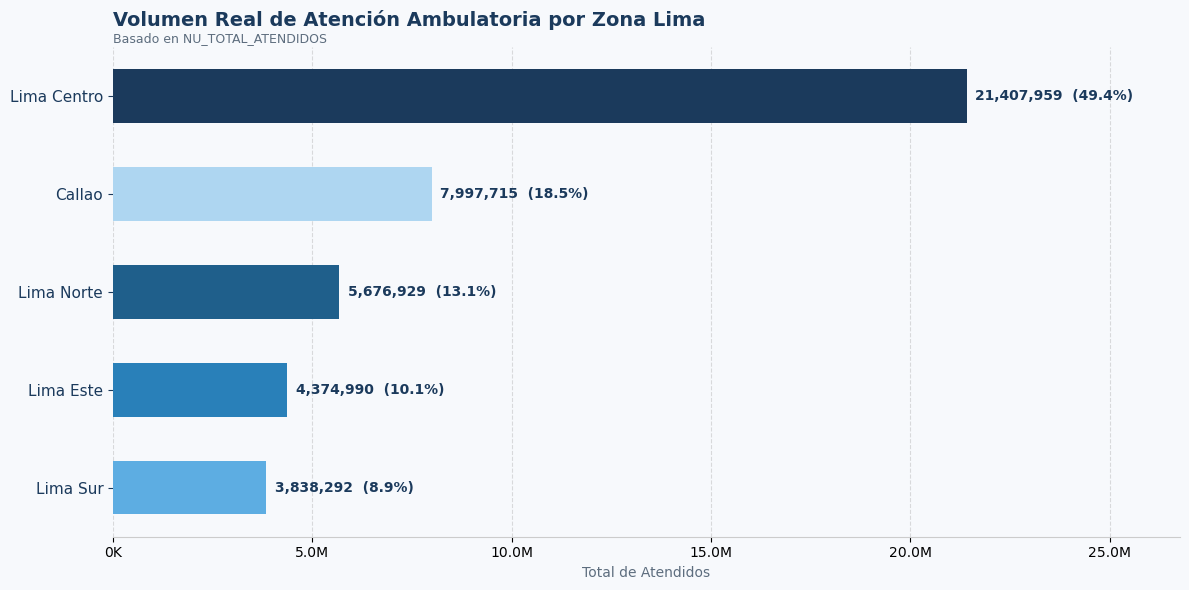

✅ Gráfico guardado!


In [37]:
# ── Gráfico con NU_TOTAL_ATENDIDOS real ──────────────────
import matplotlib.pyplot as plt

# Separar fuera de Lima antes de graficar
fuera = resumen_real[resumen_real["ZONA_LIMA"] == "Fuera de Lima"]
if not fuera.empty:
    print(f"⚠️  Excluidos del gráfico — Fuera de Lima: {fuera['Total'].values[0]:,.0f}")

resumen_graf = (resumen_real[resumen_real["ZONA_LIMA"] != "Fuera de Lima"]
                .sort_values("Total", ascending=True))

colores_zona = {
    "Lima Centro": "#1B3A5C",
    "Lima Norte" : "#1F5F8B",
    "Lima Este"  : "#2980B9",
    "Lima Sur"   : "#5DADE2",
    "Callao"     : "#AED6F1"
}

colores = [colores_zona[z] for z in resumen_graf["ZONA_LIMA"]]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#F7F9FC")
ax.set_facecolor("#F7F9FC")

bars = ax.barh(resumen_graf["ZONA_LIMA"], resumen_graf["Total"],
               color=colores, edgecolor="none", height=0.55)

for bar, valor, zona in zip(bars, resumen_graf["Total"], resumen_graf["ZONA_LIMA"]):
    pct = resumen_graf[resumen_graf["ZONA_LIMA"] == zona]["%"].values[0]
    ax.text(bar.get_width() + resumen_graf["Total"].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{valor:,.0f}  ({pct}%)",
            va="center", fontsize=10,
            fontweight="bold", color="#1B3A5C")

ax.set_title("Volumen Real de Atención Ambulatoria por Zona Lima",
             fontsize=14, fontweight="bold", color="#1B3A5C", loc="left", pad=15)
ax.text(0, 1.01, "Basado en NU_TOTAL_ATENDIDOS",
        transform=ax.transAxes, fontsize=9, color="#5D6D7E")
ax.set_xlabel("Total de Atendidos", fontsize=10, color="#5D6D7E")
ax.xaxis.grid(True, linestyle="--", alpha=0.4, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_xlim(0, resumen_graf["Total"].max() * 1.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{int(x/1e3)}K"))
ax.tick_params(axis="y", labelsize=11, colors="#1B3A5C")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")

plt.tight_layout()
plt.savefig("volumen_real_zonas.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado!")

##### Este Top 8 evidencia que en Lima, la mayor atención ambulatoria se concentra en Lima Centro, donde el distrito de Lima lidera ampliamente, seguido por San Isidro y Jesús María. Esto indica que esta zona concentra la mayor oferta de servicios de salud y atención especializada

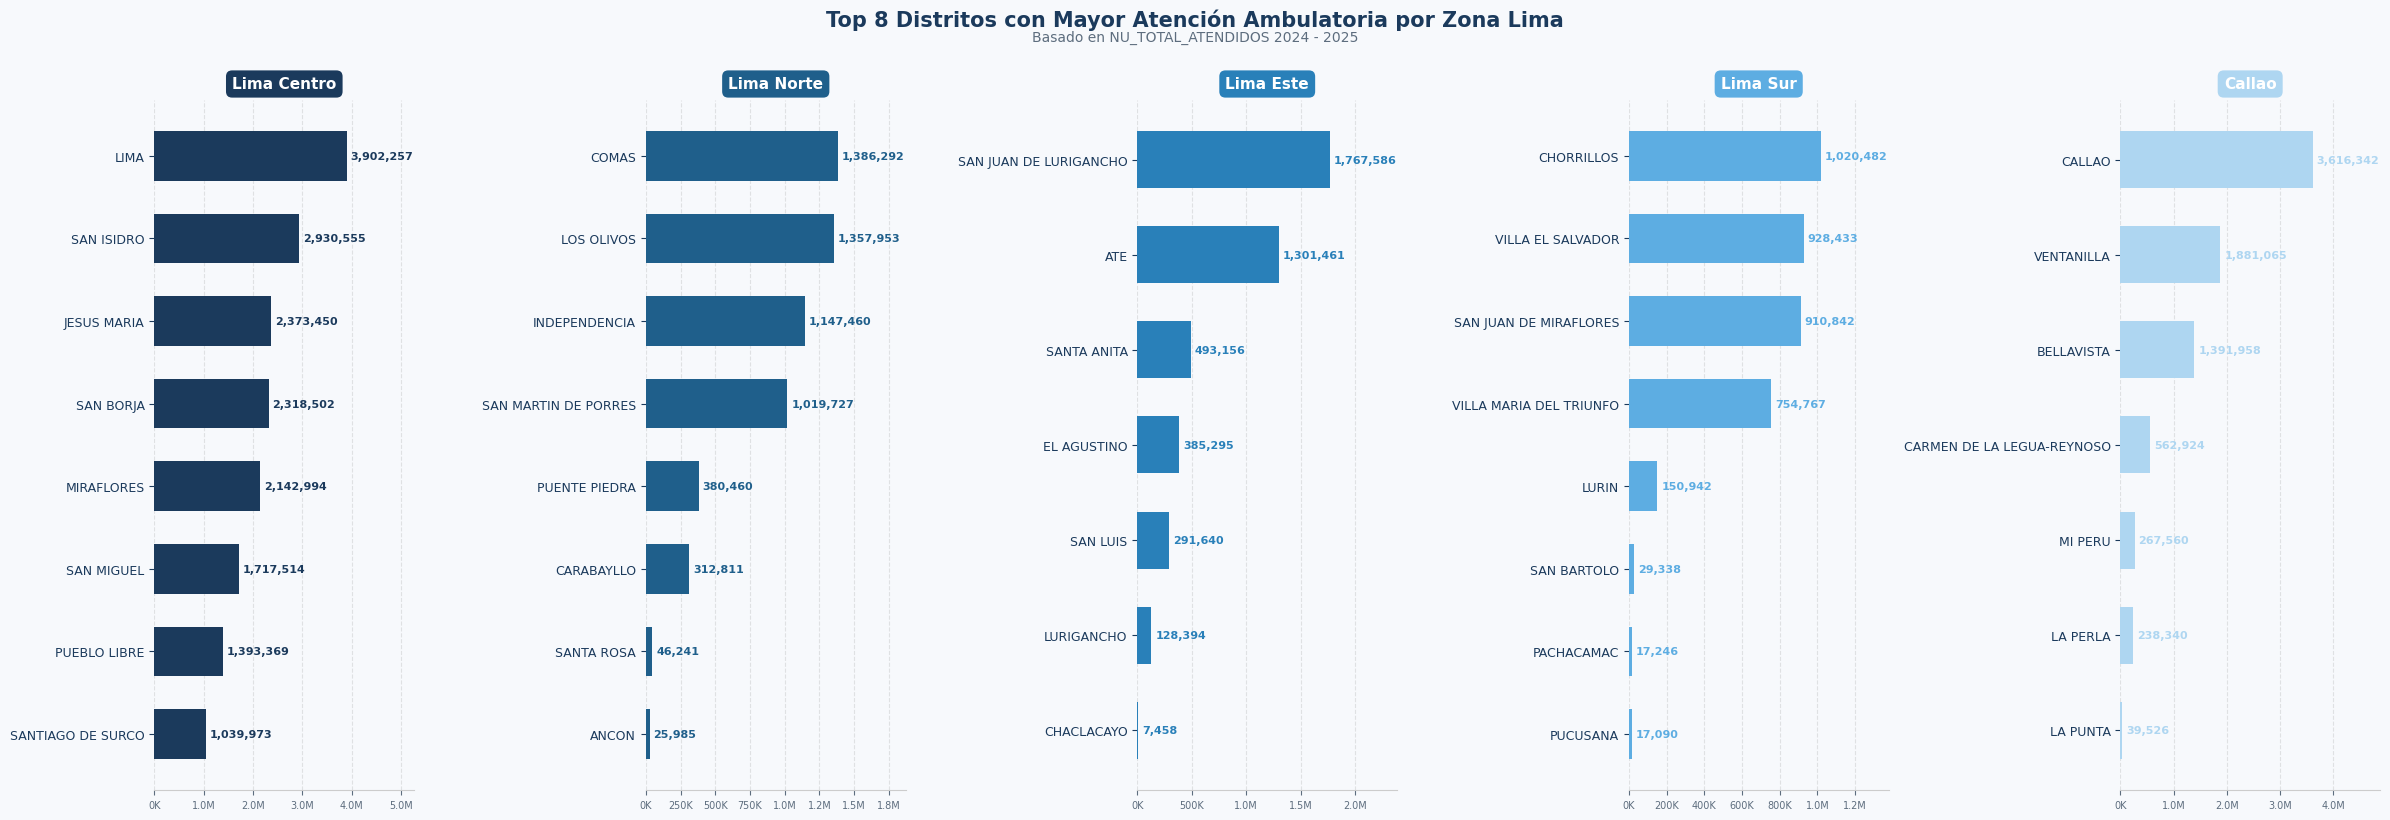

📊 TOP 8 DISTRITOS POR ZONA — NU_TOTAL_ATENDIDOS

📍 Lima Centro
---------------------------------------------
   LIMA                            3,902,257
   SAN ISIDRO                      2,930,555
   JESUS MARIA                     2,373,450
   SAN BORJA                       2,318,502
   MIRAFLORES                      2,142,994
   SAN MIGUEL                      1,717,514
   PUEBLO LIBRE                    1,393,369
   SANTIAGO DE SURCO               1,039,973

📍 Lima Norte
---------------------------------------------
   COMAS                           1,386,292
   LOS OLIVOS                      1,357,953
   INDEPENDENCIA                   1,147,460
   SAN MARTIN DE PORRES            1,019,727
   PUENTE PIEDRA                     380,460
   CARABAYLLO                        312,811
   SANTA ROSA                         46,241
   ANCON                              25,985

📍 Lima Este
---------------------------------------------
   SAN JUAN DE LURIGANCHO          1,767,586
   ATE 

In [38]:
# ── Top 8 distritos por zona con NU_TOTAL_ATENDIDOS ──────
import matplotlib.pyplot as plt

data_total["NU_TOTAL_ATENDIDOS"] = pd.to_numeric(
    data_total["NU_TOTAL_ATENDIDOS"], errors="coerce")

top_distritos = (data_total.groupby(["ZONA_LIMA", "DISTRITO"])["NU_TOTAL_ATENDIDOS"]
                 .sum()
                 .reset_index(name="Total")
                 .sort_values("Total", ascending=False)
                 .groupby("ZONA_LIMA")
                 .head(8)
                 .sort_values(["ZONA_LIMA", "Total"], ascending=[True, True]))

colores_zona = {
    "Lima Centro": "#1B3A5C",
    "Lima Norte":  "#1F5F8B",
    "Lima Este":   "#2980B9",
    "Lima Sur":    "#5DADE2",
    "Callao":      "#AED6F1"
}

zonas = ["Lima Centro", "Lima Norte", "Lima Este", "Lima Sur", "Callao"]

fig, axes = plt.subplots(1, 5, figsize=(24, 8))
fig.patch.set_facecolor("#F7F9FC")
fig.suptitle("Top 8 Distritos con Mayor Atención Ambulatoria por Zona Lima",
             fontsize=15, fontweight="bold", color="#1B3A5C", y=1.02)
fig.text(0.5, 0.98, "Basado en NU_TOTAL_ATENDIDOS 2024 - 2025",
         ha="center", fontsize=10, color="#5D6D7E")

for ax, zona in zip(axes, zonas):
    df_zona = top_distritos[top_distritos["ZONA_LIMA"] == zona].copy()
    color   = colores_zona[zona]

    ax.set_facecolor("#F7F9FC")
    bars = ax.barh(df_zona["DISTRITO"], df_zona["Total"],
                   color=color, edgecolor="none", height=0.6)

    for bar, valor in zip(bars, df_zona["Total"]):
        ax.text(bar.get_width() + df_zona["Total"].max() * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f"{valor:,.0f}", va="center", fontsize=8,
                fontweight="bold", color=color)

    ax.set_title(zona, fontsize=11, fontweight="bold", color="white", pad=8,
                 bbox=dict(boxstyle="round,pad=0.4", facecolor=color, edgecolor="none"))

    ax.xaxis.grid(True, linestyle="--", alpha=0.3, color="#AAAAAA")
    ax.set_axisbelow(True)
    ax.set_xlim(0, df_zona["Total"].max() * 1.35)
    ax.tick_params(axis="y", labelsize=9, colors="#1B3A5C")
    ax.tick_params(axis="x", labelsize=7, colors="#5D6D7E")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(
        lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{int(x/1e3)}K"))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#CCCCCC")

plt.tight_layout()
plt.savefig("distritos_nu_total_atendidos.png", dpi=200, bbox_inches="tight")
plt.show()

# ── Tabla resumen ────────────────────────────────────────
print("=" * 55)
print("📊 TOP 8 DISTRITOS POR ZONA — NU_TOTAL_ATENDIDOS")
print("=" * 55)
for zona in zonas:
    df = top_distritos[top_distritos["ZONA_LIMA"] == zona].sort_values("Total", ascending=False)
    print(f"\n📍 {zona}")
    print("-" * 45)
    for _, row in df.iterrows():
        print(f"   {row['DISTRITO']:<30} {row['Total']:>10,.0f}")
print("=" * 55)

## Atención hospitalario

In [39]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### Se automatizó la lectura y consolidación de datos 2024–2025 de la atención hospitalaria en un único dataset para facilitar el análisis

In [40]:
#Lectura
import os
import pandas as pd

ruta_base = r"C:\Users\PROPIETARIO\Desktop\PROGRAMACIÓN\PRACTICANDO-PYTHON\PROYECTO CLINICA\atencion hospitalaria"

# ── Ver archivos ─────────────────────────────────────────
print("📂 Archivos encontrados:")
for archivo in os.listdir(ruta_base):
    print(f"  - {archivo}")

📂 Archivos encontrados:
  - ConsultaD1_2024_v22.csv
  - ConsultaD1_2025_v20.csv


##### Se realizó un proceso de ETL, consolidando múltiples fuentes en un único dataset estructurado, lo que permitió garantizar consistencia y escalabilidad en el análisis.

In [41]:
## TOTAL DE FILAS Y COLUMNAS 

archivos = [f for f in os.listdir(ruta_base) if f.endswith(".xlsx") or f.endswith(".csv")]

dataframes = []
for archivo in archivos:
    ruta = os.path.join(ruta_base, archivo)
    df = pd.read_excel(ruta) if archivo.endswith(".xlsx") else pd.read_csv(ruta, encoding="latin-1", sep=";")
    print(f"✅ {archivo} — {len(df)} filas")
    dataframes.append(df)

data_hosp_total = pd.concat(dataframes, ignore_index=True)
print(f"\n📊 Total: {len(data_hosp_total)} filas")
print(f"📋 Columnas: {data_hosp_total.columns.tolist()}")

✅ ConsultaD1_2024_v22.csv — 74131 filas
✅ ConsultaD1_2025_v20.csv — 88646 filas

📊 Total: 162777 filas
📋 Columnas: ['ANHO', 'MES', 'UBIGEO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'SECTOR', 'CATEGORIA', 'CO_IPRESS', 'RAZON_SOC', 'ID_HOSPITALIZACION', 'HOSPITALIZACION', 'NRO_TOTAL_HOSPIT_ING', 'NRO_TOTAL_HOSPIT_EGR', 'NRO_TOTAL_ESTANCIAS', 'NRO_TOTAL_PACIENTES_CAMAS', 'NRO_TOTAL_CAMAS', 'DIAS_CAMA_DISPONIBLE', 'NRO_TOTAL_FALLECIDOS']


##### Luego se clasifica los datos por zonas estratégicas de Lima (Lima Norte, Sur, Centro, Este o Callao). Esto me permitió filtrar solo los registros relevantes y analizar la distribución de atenciones dentro de Lima Metropolitana.”

### Clasificación por Distritos

In [42]:
# ── PASO 2: Clasificar por Zonas  ───────────────
lima_norte  = ["Ancón", "Carabayllo", "Comas", "Independencia",
               "Los Olivos", "Puente Piedra", "San Martín De Porres",
               "San Martin De Porres",          # sin tilde
               "Santa Rosa", "Ancón", "Ancon"]  # alias sin tilde

lima_sur    = ["Chorrillos", "Lurín", "Lurin", "Pachacamac", "Pucusana",
               "Punta Hermosa", "Punta Negra", "San Bartolo",
               "San Juan De Miraflores", "Santa María", "Santa Maria",
               "Santa Maria Del Mar",
               "Villa El Salvador",
               "Villa María Del Triunfo", "Villa Maria Del Triunfo"]

lima_centro = ["Barranco", "Breña", "Brena", "Jesús María", "Jesus Maria",
               "La Molina", "La Victoria", "Lima", "Lince",
               "Magdalena", "Magdalena Del Mar",
               "Miraflores", "Pueblo Libre",
               "Rímac", "Rimac",
               "San Borja", "San Isidro", "San Miguel",
               "Santiago De Surco", "Surco", "Surquillo"]

lima_este   = ["Ate", "Chaclacayo", "Cieneguilla", "El Agustino",
               "Lurigancho", "San Juan De Lurigancho", "San Luis", "Santa Anita"]

callao      = ["Bellavista", "Callao",
               "Carmen De La Legua-Reynoso",   # con guión
               "Carmen De La Legua Reynoso",   # sin guión
               "La Perla", "La Punta",
               "Mi Perú", "Mi Peru",
               "Ventanilla"]

def asignar_zona(distrito):
    if distrito in lima_norte:   return "Lima Norte"
    if distrito in lima_sur:     return "Lima Sur"
    if distrito in lima_centro:  return "Lima Centro"
    if distrito in lima_este:    return "Lima Este"
    if distrito in callao:       return "Callao"
    return "Fuera de Lima"

# ⚠️ Reemplaza "DISTRITO" por el nombre real de tu columna
data_hosp_total["ZONA_LIMA"] = data_hosp_total["DISTRITO"].str.title().map(asignar_zona)
data_hosp_lima = data_hosp_total[data_hosp_total["ZONA_LIMA"] != "Fuera de Lima"].copy()

print(f"✅ Total Lima: {len(data_hosp_lima)} filas")

✅ Total Lima: 25269 filas


##### Con esto identifico los distritos que no e registrado para evitar cualquier perdida de información

In [43]:
# ── Ver distritos que caen en "Fuera de Lima" ────────────
sin_zona = (
    data_hosp_total[data_hosp_total["ZONA_LIMA"] == "Fuera de Lima"]
    .groupby("DISTRITO")
    .size()
    .reset_index(name="Cantidad")
    .sort_values("Cantidad", ascending=False)
)

print(f"⚠️  Registros sin zona : {sin_zona['Cantidad'].sum():,}")
print(f"📍 Distritos únicos   : {len(sin_zona)}\n")
print(sin_zona.to_string(index=False))

⚠️  Registros sin zona : 137,508
📍 Distritos únicos   : 1054

                      DISTRITO  Cantidad
                       WANCHAQ      3456
                      TRUJILLO      2555
                      CHICLAYO      2108
                      EL TAMBO      1818
                     CAJAMARCA      1765
                      AREQUIPA      1687
                       CUTERVO      1498
                         CUSCO      1496
                      CALLERIA      1470
                           ICA      1470
                      HUANCAYO      1280
                     MOYOBAMBA      1182
                          JAEN      1113
                       JULIACA      1102
                          PUNO      1024
                        PANGOA       989
                       PALCAZU       959
                      CHIMBOTE       932
               PUERTO BERMUDEZ       891
                      PUNCHANA       817
                      TARAPOTO       794
                         TACNA      

### Gráfico de atención Hospitalaria

In [44]:
# ── Verificar que todo está listo ────────────────────────
print(f"✅ Total Lima: {len(data_hosp_lima)} filas")
print(f"📊 Por zona:")
print(data_hosp_lima.groupby("ZONA_LIMA").size().reset_index(name="Total"))

✅ Total Lima: 25269 filas
📊 Por zona:
     ZONA_LIMA  Total
0       Callao   4045
1  Lima Centro  13364
2    Lima Este   2996
3   Lima Norte   2775
4     Lima Sur   2089


In [45]:
print(data_hosp_lima.columns.tolist())

['ANHO', 'MES', 'UBIGEO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'SECTOR', 'CATEGORIA', 'CO_IPRESS', 'RAZON_SOC', 'ID_HOSPITALIZACION', 'HOSPITALIZACION', 'NRO_TOTAL_HOSPIT_ING', 'NRO_TOTAL_HOSPIT_EGR', 'NRO_TOTAL_ESTANCIAS', 'NRO_TOTAL_PACIENTES_CAMAS', 'NRO_TOTAL_CAMAS', 'DIAS_CAMA_DISPONIBLE', 'NRO_TOTAL_FALLECIDOS', 'ZONA_LIMA']


##### Se analizó la distribución de ingresos hospitalarios por zonas de Lima, realizando limpieza de datos, agregación por ubicación geográfica y cálculo de participaciones porcentuales para identificar zonas con mayor demanda

In [46]:
# ── Total NRO_TOTAL_HOSPIT_ING por zona ──────────────────
data_hosp_lima["NRO_TOTAL_HOSPIT_ING"] = pd.to_numeric(
    data_hosp_lima["NRO_TOTAL_HOSPIT_ING"], errors="coerce")

resumen_hosp = (data_hosp_lima.groupby("ZONA_LIMA")["NRO_TOTAL_HOSPIT_ING"]
                .sum()
                .reset_index(name="Total")
                .sort_values("Total", ascending=False))

resumen_hosp["%"] = (resumen_hosp["Total"] / resumen_hosp["Total"].sum() * 100).round(1)

print("=" * 55)
print("📊 INGRESOS HOSPITALARIOS POR ZONA")
print("=" * 55)
for _, row in resumen_hosp.iterrows():
    print(f"  {row['ZONA_LIMA']:<15} {row['Total']:>15,.0f}  ({row['%']}%)")
print("-" * 55)
print(f"  {'TOTAL GENERAL':<15} {resumen_hosp['Total'].sum():>15,.0f}  (100%)")

📊 INGRESOS HOSPITALARIOS POR ZONA
  Lima Centro           2,540,167  (81.1%)
  Lima Este               165,820  (5.3%)
  Lima Norte              161,348  (5.2%)
  Callao                  149,878  (4.8%)
  Lima Sur                113,766  (3.6%)
-------------------------------------------------------
  TOTAL GENERAL         3,130,979  (100%)


##### Los resultados muestran una alta concentración de ingresos hospitalarios en Lima Centro, que representa el 81.1% del total. En contraste, zonas como Lima Sur, Callao, Lima Norte y Lima Este presentan participaciones significativamente menores, todas por debajo del 6%

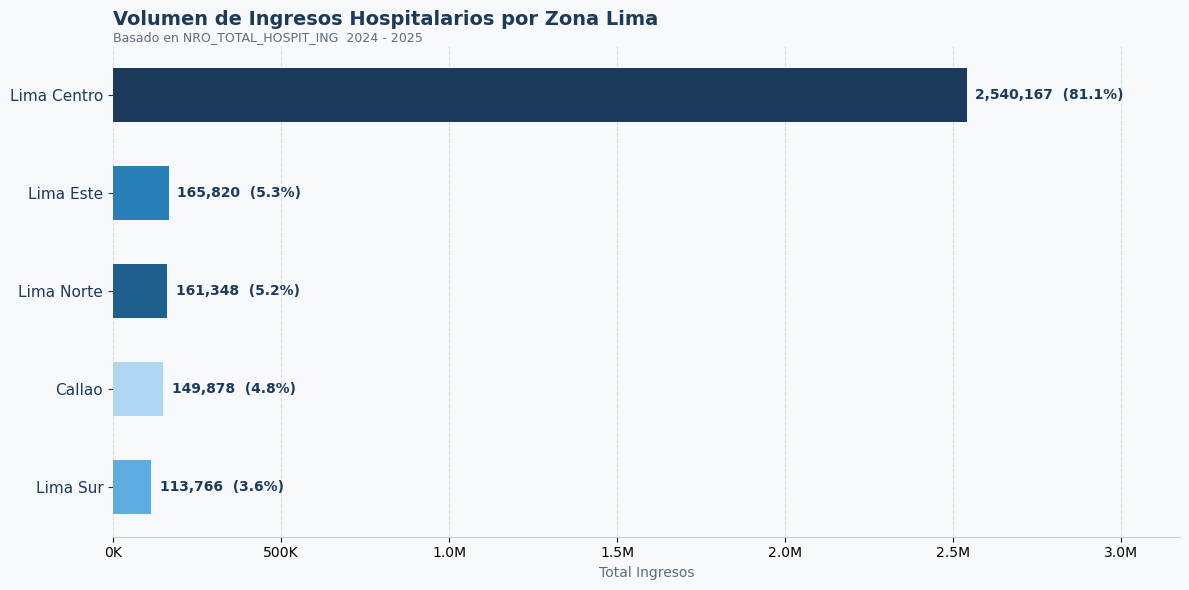

✅ Gráfico 1 guardado!


In [47]:
# ════════════════════════════════════════════════════════
# GRÁFICO 1 — Ingresos hospitalarios por zona
# ════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

resumen_hosp = resumen_hosp.sort_values("Total", ascending=True)

colores_zona = {
    "Lima Centro": "#1B3A5C",
    "Lima Norte":  "#1F5F8B",
    "Lima Este":   "#2980B9",
    "Lima Sur":    "#5DADE2",
    "Callao":      "#AED6F1"
}

colores = [colores_zona[z] for z in resumen_hosp["ZONA_LIMA"]]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#F7F9FC")
ax.set_facecolor("#F7F9FC")

bars = ax.barh(resumen_hosp["ZONA_LIMA"], resumen_hosp["Total"],
               color=colores, edgecolor="none", height=0.55)

for bar, valor, zona in zip(bars, resumen_hosp["Total"], resumen_hosp["ZONA_LIMA"]):
    pct = resumen_hosp[resumen_hosp["ZONA_LIMA"] == zona]["%"].values[0]
    ax.text(bar.get_width() + resumen_hosp["Total"].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{valor:,.0f}  ({pct}%)",
            va="center", fontsize=10,
            fontweight="bold", color="#1B3A5C")

ax.set_title("Volumen de Ingresos Hospitalarios por Zona Lima",
             fontsize=14, fontweight="bold", color="#1B3A5C", loc="left", pad=15)
ax.text(0, 1.01, "Basado en NRO_TOTAL_HOSPIT_ING  2024 - 2025",
        transform=ax.transAxes, fontsize=9, color="#5D6D7E")
ax.set_xlabel("Total Ingresos", fontsize=10, color="#5D6D7E")
ax.xaxis.grid(True, linestyle="--", alpha=0.4, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_xlim(0, resumen_hosp["Total"].max() * 1.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{int(x/1e3)}K"))
ax.tick_params(axis="y", labelsize=11, colors="#1B3A5C")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")

plt.tight_layout()
plt.savefig("hosp_zonas.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráfico 1 guardado!")

##### Ahora Observaremos con mas detalle de los top 8 de la distribución de lima para sacar mejores resultados

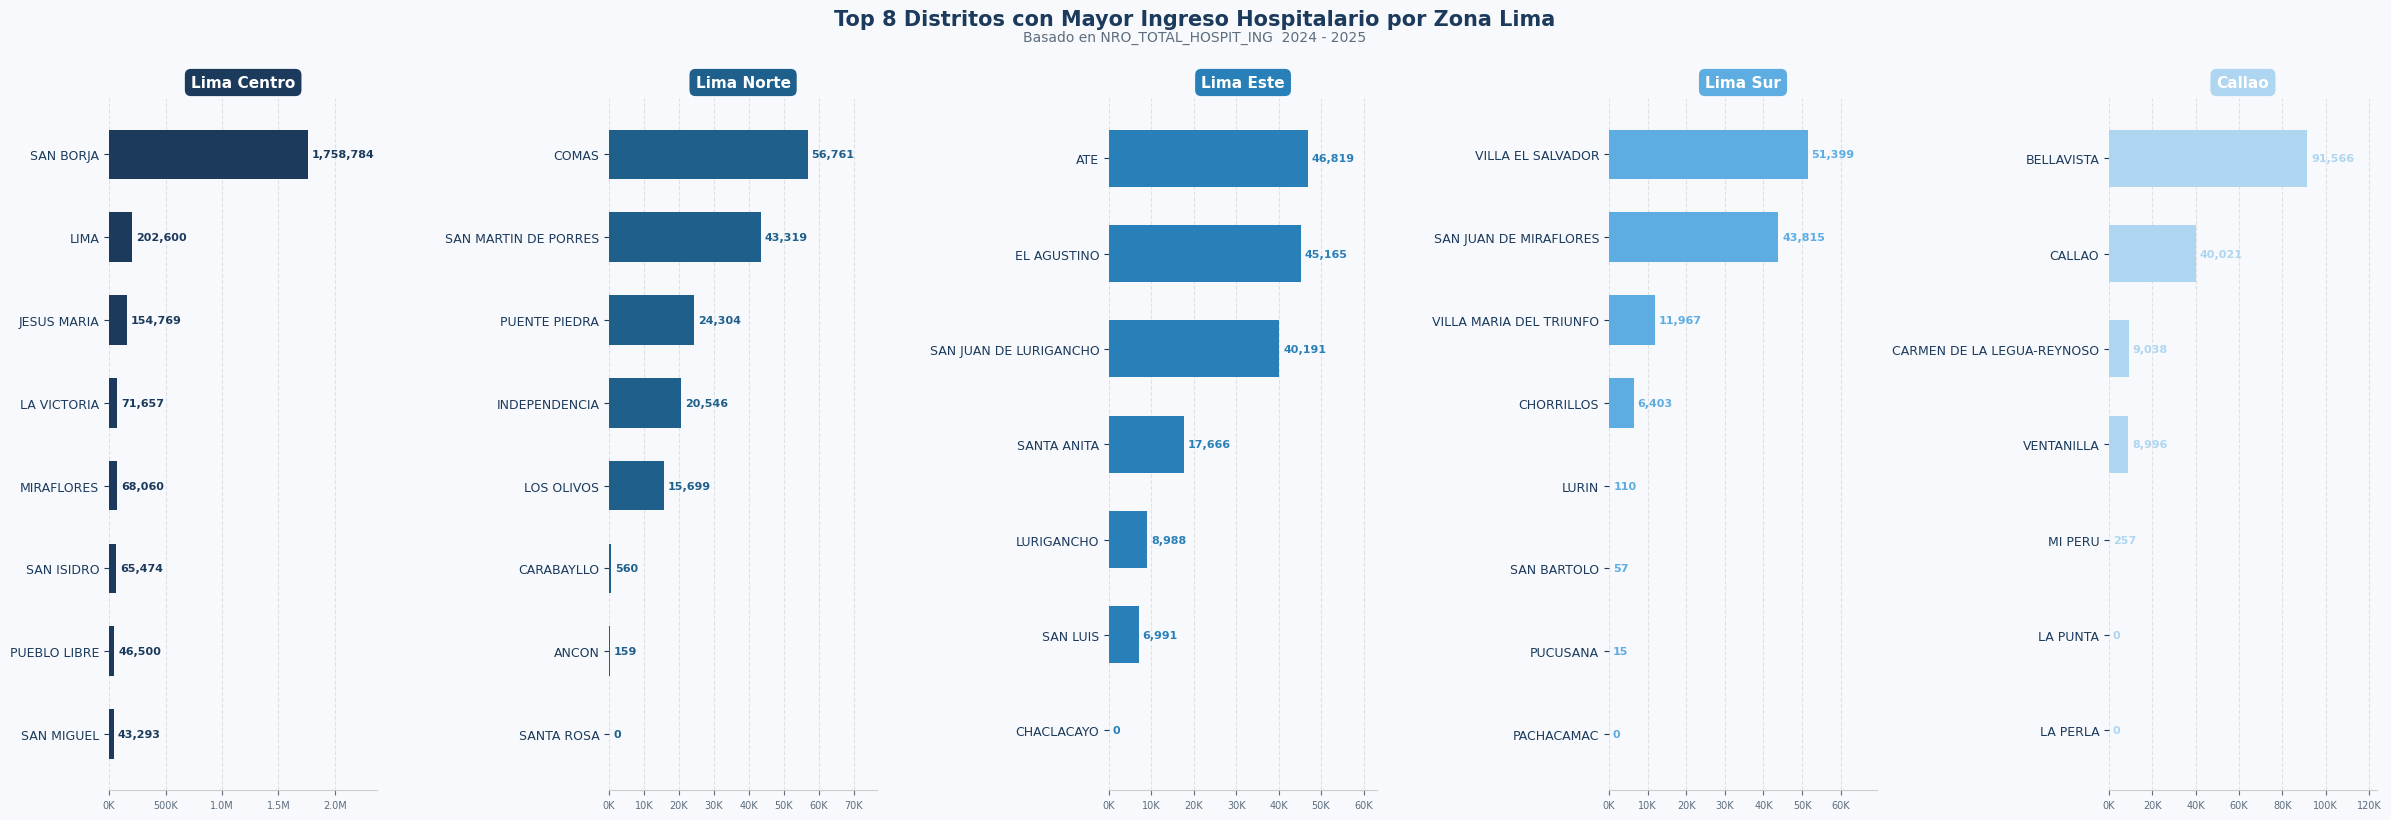

✅ Gráfico 2 guardado!


In [48]:
# ════════════════════════════════════════════════════════
# GRÁFICO 2 — Top 8 distritos por zona
# ════════════════════════════════════════════════════════
top_distritos = (data_hosp_lima.groupby(["ZONA_LIMA", "DISTRITO"])["NRO_TOTAL_HOSPIT_ING"]
                 .sum()
                 .reset_index(name="Total")
                 .sort_values("Total", ascending=False)
                 .groupby("ZONA_LIMA")
                 .head(8)
                 .sort_values(["ZONA_LIMA", "Total"], ascending=[True, True]))

zonas = ["Lima Centro", "Lima Norte", "Lima Este", "Lima Sur", "Callao"]

fig, axes = plt.subplots(1, 5, figsize=(24, 8))
fig.patch.set_facecolor("#F7F9FC")
fig.suptitle("Top 8 Distritos con Mayor Ingreso Hospitalario por Zona Lima",
             fontsize=15, fontweight="bold", color="#1B3A5C", y=1.02)
fig.text(0.5, 0.98, "Basado en NRO_TOTAL_HOSPIT_ING  2024 - 2025",
         ha="center", fontsize=10, color="#5D6D7E")

for ax, zona in zip(axes, zonas):
    df_zona = top_distritos[top_distritos["ZONA_LIMA"] == zona].copy()
    color   = colores_zona[zona]

    ax.set_facecolor("#F7F9FC")
    bars = ax.barh(df_zona["DISTRITO"], df_zona["Total"],
                   color=color, edgecolor="none", height=0.6)

    for bar, valor in zip(bars, df_zona["Total"]):
        ax.text(bar.get_width() + df_zona["Total"].max() * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f"{valor:,.0f}", va="center", fontsize=8,
                fontweight="bold", color=color)

    ax.set_title(zona, fontsize=11, fontweight="bold", color="white", pad=8,
                 bbox=dict(boxstyle="round,pad=0.4", facecolor=color, edgecolor="none"))

    ax.xaxis.grid(True, linestyle="--", alpha=0.3, color="#AAAAAA")
    ax.set_axisbelow(True)
    ax.set_xlim(0, df_zona["Total"].max() * 1.35)
    ax.tick_params(axis="y", labelsize=9, colors="#1B3A5C")
    ax.tick_params(axis="x", labelsize=7, colors="#5D6D7E")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(
        lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{int(x/1e3)}K"))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#CCCCCC")

plt.tight_layout()
plt.savefig("hosp_distritos.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráfico 2 guardado!")

In [49]:
# ── Verificar años en data hospitalaria ─────────────────
print("📅 Años disponibles en data hospitalaria:")
print(sorted(data_hosp_lima["ANHO"].unique()))

print(f"\n📊 Registros por año:")
print(data_hosp_lima.groupby("ANHO").size().reset_index(name="Registros"))

print(f"\n🏥 Ingresos por año:")
print(data_hosp_lima.groupby("ANHO")["NRO_TOTAL_HOSPIT_ING"].sum().reset_index(name="Total Ingresos"))

📅 Años disponibles en data hospitalaria:
[np.int64(2024), np.int64(2025)]

📊 Registros por año:
   ANHO  Registros
0  2024      11874
1  2025      13395

🏥 Ingresos por año:
   ANHO  Total Ingresos
0  2024       2405744.0
1  2025        725235.0


## COMPARATIVA ENTRE ATENCIÓN HOSPITALARIA Y AMBULATORIA

In [50]:
# ════════════════════════════════════════════════════════
# COMPARATIVA AMBULATORIA vs HOSPITALARIA POR ZONA
# ════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np

# ── Datos ambulatoria ────────────────────────────────────
amb = (data_total[data_total["ZONA_LIMA"] != "Fuera de Lima"]  # ← data_total
       .groupby("ZONA_LIMA")["NU_TOTAL_ATENDIDOS"]
       .sum()
       .reset_index(name="Ambulatoria"))

# ── Datos hospitalaria ───────────────────────────────────
hosp = (data_hosp_lima.groupby("ZONA_LIMA")["NRO_TOTAL_HOSPIT_ING"]
        .sum()
        .reset_index(name="Hospitalaria"))

# ── Unir ─────────────────────────────────────────────────
comparativa = amb.merge(hosp, on="ZONA_LIMA")
print(comparativa)

     ZONA_LIMA  Ambulatoria  Hospitalaria
0       Callao    7997715.0      149878.0
1  Lima Centro   21407959.0     2540167.0
2    Lima Este    4374990.0      165820.0
3   Lima Norte    5676929.0      161348.0
4     Lima Sur    3838292.0      113766.0


### Gráfica comparativa ambulatoria vs Hospitalaria de Lima Norte,Este,Sur,Centro y Callao

##### Observaremos a nivel de lima para ver en que sector de lima hay mas demanda y/o casos

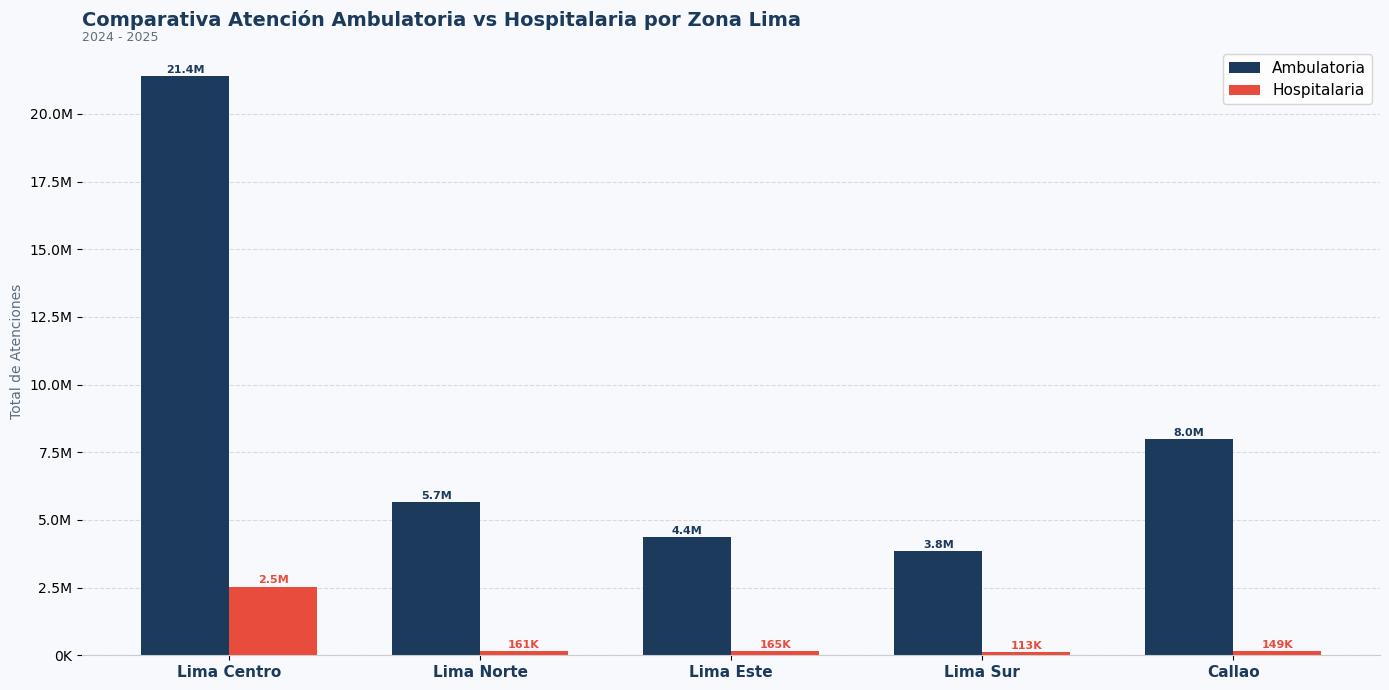

✅ Gráfico 1 guardado!


In [54]:
# ════════════════════════════════════════════════════════
# GRÁFICO 1 — Comparativa por ZONA
# ════════════════════════════════════════════════════════
zonas  = ["Lima Centro", "Lima Norte", "Lima Este", "Lima Sur", "Callao"]
x      = np.arange(len(zonas))
ancho  = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("#F7F9FC")
ax.set_facecolor("#F7F9FC")

b1 = ax.bar(x - ancho/2,
            [comparativa[comparativa["ZONA_LIMA"] == z]["Ambulatoria"].values[0] for z in zonas],
            ancho, label="Ambulatoria", color="#1B3A5C", edgecolor="none")

b2 = ax.bar(x + ancho/2,
            [comparativa[comparativa["ZONA_LIMA"] == z]["Hospitalaria"].values[0] for z in zonas],
            ancho, label="Hospitalaria", color="#E74C3C", edgecolor="none")

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + ax.get_ylim()[1] * 0.005,
            f"{bar.get_height()/1e6:.1f}M" if bar.get_height() >= 1e6 else f"{int(bar.get_height()/1e3)}K",
            ha="center", fontsize=8, fontweight="bold", color="#1B3A5C")

for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + ax.get_ylim()[1] * 0.005,
            f"{bar.get_height()/1e6:.1f}M" if bar.get_height() >= 1e6 else f"{int(bar.get_height()/1e3)}K",
            ha="center", fontsize=8, fontweight="bold", color="#E74C3C")

ax.set_xticks(x)
ax.set_xticklabels(zonas, fontsize=11, color="#1B3A5C", fontweight="bold")
ax.set_title("Comparativa Atención Ambulatoria vs Hospitalaria por Zona Lima",
             fontsize=14, fontweight="bold", color="#1B3A5C", loc="left", pad=15)
ax.text(0, 1.01, "2024 - 2025",
        transform=ax.transAxes, fontsize=9, color="#5D6D7E")
ax.set_ylabel("Total de Atenciones", fontsize=10, color="#5D6D7E")
ax.yaxis.grid(True, linestyle="--", alpha=0.4, color="#AAAAAA")
ax.set_axisbelow(True)
ax.legend(fontsize=11, framealpha=0.8, edgecolor="#CCCCCC")
ax.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{int(x/1e3)}K"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")

plt.tight_layout()
plt.savefig("comparativa_amb_hosp_zonas.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráfico 1 guardado!")

### Gráfico a nivel de distritos

##### Observaremos un poco mas a detalle ahora a nivel de distritos para ver que tanta diferencia se da en los casos

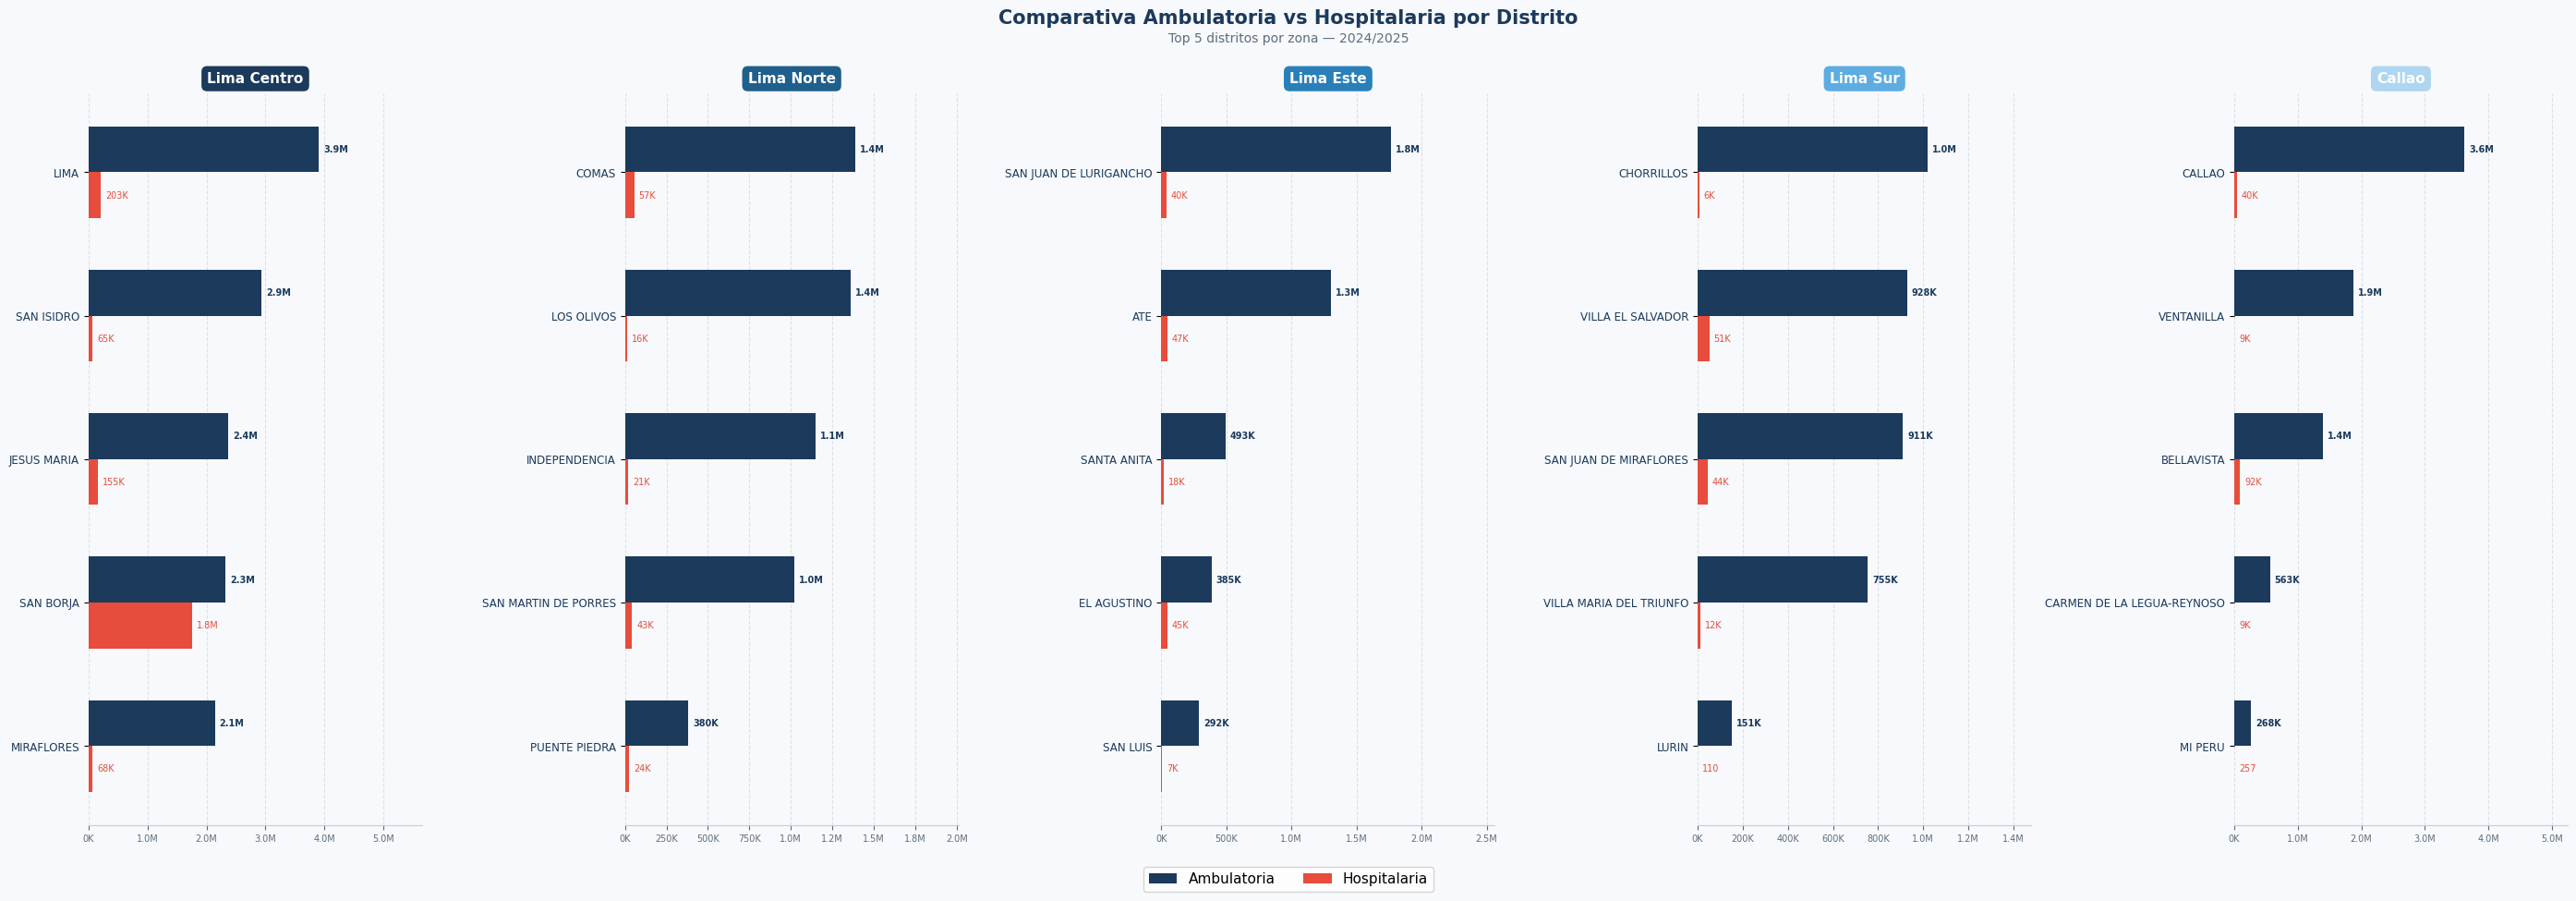

✅ Gráfico por distritos guardado!


In [55]:
# ════════════════════════════════════════════════════════
# COMPARATIVA AMBULATORIA vs HOSPITALARIA — POR DISTRITO
# ════════════════════════════════════════════════════════

# ── 1. Agrupar por distrito ───────────────────────────────
amb_dist = (data_total_lima
            .groupby(["ZONA_LIMA", "DISTRITO"])["NU_TOTAL_ATENDIDOS"]
            .sum().reset_index(name="Ambulatoria"))

hosp_dist = (data_hosp_lima
             .groupby(["ZONA_LIMA", "DISTRITO"])["NRO_TOTAL_HOSPIT_ING"]
             .sum().reset_index(name="Hospitalaria"))

# ── 2. Unir ambas tablas ──────────────────────────────────
comp_dist = amb_dist.merge(hosp_dist, on=["ZONA_LIMA", "DISTRITO"], how="outer").fillna(0)
comp_dist = comp_dist.sort_values("Ambulatoria", ascending=False)

# ── 3. Top N por zona (ajusta el número) ──────────────────
TOP = 5   # ← cambia a 8, 10, etc. según quieras

top_dist = (comp_dist
            .sort_values("Ambulatoria", ascending=False)
            .groupby("ZONA_LIMA")
            .head(TOP)
            .sort_values(["ZONA_LIMA", "Ambulatoria"], ascending=[True, True]))

# ── 4. Gráfico ────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(28, 9))
fig.patch.set_facecolor("#F7F9FC")
fig.suptitle("Comparativa Ambulatoria vs Hospitalaria por Distrito",
             fontsize=15, fontweight="bold", color="#1B3A5C", y=1.02)
fig.text(0.5, 0.98, f"Top {TOP} distritos por zona — 2024/2025",
         ha="center", fontsize=10, color="#5D6D7E")

for ax, zona in zip(axes, zonas):
    df    = top_dist[top_dist["ZONA_LIMA"] == zona].copy()
    color = colores_zona[zona]
    y     = np.arange(len(df))
    alto  = 0.32

    ax.set_facecolor("#F7F9FC")

    # Barras
    b_amb  = ax.barh(y + alto/2, df["Ambulatoria"],  alto,
                     color="#1B3A5C", edgecolor="none", label="Ambulatoria")
    b_hosp = ax.barh(y - alto/2, df["Hospitalaria"], alto,
                     color="#E74C3C", edgecolor="none", label="Hospitalaria")

    # Etiquetas ambulatoria
    for bar in b_amb:
        v = bar.get_width()
        if v > 0:
            ax.text(v + df["Ambulatoria"].max() * 0.02,
                    bar.get_y() + bar.get_height() / 2,
                    f"{v/1e6:.1f}M" if v >= 1e6 else f"{v/1e3:.0f}K" if v >= 1000 else f"{int(v)}",
                    va="center", fontsize=7, fontweight="bold", color="#1B3A5C")

    # Etiquetas hospitalaria
    for bar in b_hosp:
        v = bar.get_width()
        if v > 0:
            ax.text(v + df["Ambulatoria"].max() * 0.02,
                    bar.get_y() + bar.get_height() / 2,
                    f"{v/1e6:.1f}M" if v >= 1e6 else f"{v/1e3:.0f}K" if v >= 1000 else f"{int(v)}",
                    va="center", fontsize=7, color="#E74C3C")

    # Formato ejes
    ax.set_yticks(y)
    ax.set_yticklabels(df["DISTRITO"], fontsize=8.5, color="#1B3A5C")
    ax.set_title(zona, fontsize=11, fontweight="bold", color="white", pad=8,
                 bbox=dict(boxstyle="round,pad=0.4", facecolor=color, edgecolor="none"))
    ax.xaxis.grid(True, linestyle="--", alpha=0.3, color="#AAAAAA")
    ax.set_axisbelow(True)
    ax.set_xlim(0, df["Ambulatoria"].max() * 1.45)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(
        lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{int(x/1e3)}K"))
    ax.tick_params(axis="x", labelsize=7, colors="#5D6D7E")
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#CCCCCC")

# Leyenda
from matplotlib.patches import Patch
leyenda = [Patch(facecolor="#1B3A5C", label="Ambulatoria"),
           Patch(facecolor="#E74C3C", label="Hospitalaria")]
fig.legend(handles=leyenda, loc="lower center", ncol=2,
           fontsize=11, framealpha=0.8, edgecolor="#CCCCCC",
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig("comparativa_distritos.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráfico por distritos guardado!")

## Camas

In [1]:
# ── Cargar archivos de camas ─────────────────────────────
import pandas as pd
import os

ruta_base = r"C:\Users\PROPIETARIO\Desktop\PROGRAMACIÓN\PRACTICANDO-PYTHON\PROYECTO CLINICA\camas"

archivos = [f for f in os.listdir(ruta_base) if f.endswith(".csv")]

dataframes = []
for archivo in archivos:
    ruta = os.path.join(ruta_base, archivo)
    df = pd.read_csv(ruta, sep="|", encoding="utf-8-sig")
    print(f"✅ {archivo} — {len(df)} filas")
    dataframes.append(df)

data_camas = pd.concat(dataframes, ignore_index=True)

print(f"\n📊 Total: {len(data_camas):,} filas")
print(f"\n📋 COLUMNAS:")
for i, col in enumerate(data_camas.columns, 1):
    print(f"  {i:>2}. {col}")

✅ Camas-02_11_2022.csv — 329659 filas
✅ Camas_30-03-2021_v2.csv — 189028 filas

📊 Total: 518,687 filas

📋 COLUMNAS:
   1. FECHACORTE
   2. FECHAREGISTRO
   3. CODIGO
   4. NOMBRE
   5. CATEGORIA
   6. NIVEL
   7. INSTITUCIÓN
   8. GRUPO
   9. SUB_GRUPO
  10. MACROREGIONES
  11. UBIGEO
  12. REGION
  13. PROVINCIA
  14. DISTRITO
  15. RESPONSABLE
  16. CUENTA_TRIAJE
  17. NU_ATENC_ULT
  18. CUENTA_ZC
  19. ZC_UCI_AACT_CAM_TOTAL
  20. ZC_UCI_AACT_CAM_INOPERATIVOS
  21. ZC_UCI_AACT_CAM_TOT_OPER
  22. ZC_UCI_AACT_CAM_TOT_DISP
  23. ZC_UCI_AACT_CAM_TOT_OCUP
  24. ZC_UCI_AACT_COC_CAM_CONFIR
  25. ZC_UCI_AACT_COC_CAM_X_CONFIR
  26. ZC_UCI_AACT_COO_CAM_CANULAS
  27. ZC_UCI_AACT_COO_CAM_SIN_VM
  28. ZC_UCI_AACT_COO_CAM_CON_VM
  29. ZC_UCI_ADUL_CAM_TOTAL
  30. ZC_UCI_ADUL_CAM_INOPERATIVOS
  31. ZC_UCI_ADUL_CAM_TOT_OPER
  32. ZC_UCI_ADUL_CAM_TOT_DISP
  33. ZC_UCI_ADUL_CAM_TOT_OCUP
  34. ZC_UCI_ADUL_COC_CAM_CONFIR
  35. ZC_UCI_ADUL_COC_CAM_X_CONFIR
  36. ZC_UCI_ADUL_COO_CAM_CANULAS
  37. ZC_UCI_AD

##### Distribuimos y segmentamos en la diferente clasificación de Lima y callao para tener un mejor análisis

In [2]:
# ── PASO 1: Filtrar Lima Y Callao ─────────────────────────
data_camas_lima_region = data_camas[
    data_camas["PROVINCIA"].isin(["LIMA", "CALLAO"])
].copy()

# ── PASO 2: Crear columna unificada ───────────────────────
# Si tiene DISTRITO lo usa, si no usa PROVINCIA (caso 2021)
data_camas_lima_region["DISTRITO_REF"] = data_camas_lima_region["DISTRITO"].fillna(
    data_camas_lima_region["PROVINCIA"]
).str.title()

# ── PASO 3: Clasificar por Zonas ─────────────────────────
lima_norte  = ["Ancón", "Carabayllo", "Comas", "Independencia",
               "Los Olivos", "Puente Piedra", "San Martín De Porres",
               "San Martin De Porres", "Santa Rosa", "Ancon"]

lima_sur    = ["Chorrillos", "Lurín", "Lurin", "Pachacamac", "Pucusana",
               "Punta Hermosa", "Punta Negra", "San Bartolo",
               "San Juan De Miraflores", "Santa María", "Santa Maria",
               "Santa Maria Del Mar", "Villa El Salvador",
               "Villa María Del Triunfo", "Villa Maria Del Triunfo"]

lima_centro = ["Barranco", "Breña", "Brena", "Jesús María", "Jesus Maria",
               "La Molina", "La Victoria", "Lima", "Lince",
               "Magdalena", "Magdalena Del Mar", "Miraflores", "Pueblo Libre",
               "Rímac", "Rimac", "San Borja", "San Isidro", "San Miguel",
               "Santiago De Surco", "Surco", "Surquillo"]

lima_este   = ["Ate", "Chaclacayo", "Cieneguilla", "El Agustino",
               "Lurigancho", "San Juan De Lurigancho", "San Luis", "Santa Anita"]

callao      = ["Bellavista", "Callao",
               "Carmen De La Legua-Reynoso", "Carmen De La Legua Reynoso",
               "La Perla", "La Punta", "Mi Perú", "Mi Peru", "Ventanilla"]

def asignar_zona(distrito):
    if distrito in lima_norte:  return "Lima Norte"
    if distrito in lima_sur:    return "Lima Sur"
    if distrito in lima_centro: return "Lima Centro"
    if distrito in lima_este:   return "Lima Este"
    if distrito in callao:      return "Callao"
    return "Fuera de Lima"

data_camas_lima_region["ZONA_LIMA"] = data_camas_lima_region["DISTRITO_REF"].map(asignar_zona)

data_camas_lima = data_camas_lima_region[
    data_camas_lima_region["ZONA_LIMA"] != "Fuera de Lima"
].copy()

print(f"✅ Total clasificado: {len(data_camas_lima):,} filas")
print(f"\n📊 Distribución por zona:")
print(data_camas_lima["ZONA_LIMA"].value_counts())

print(f"\n⚠️ Sin clasificar:")
fuera = data_camas_lima_region[data_camas_lima_region["ZONA_LIMA"] == "Fuera de Lima"]
print(f"  {len(fuera):,} filas")
print(fuera["DISTRITO_REF"].dropna().value_counts().to_string())

✅ Total clasificado: 171,815 filas

📊 Distribución por zona:
ZONA_LIMA
Lima Centro    124590
Lima Norte      14108
Lima Este       11910
Callao          11419
Lima Sur         9788
Name: count, dtype: int64

⚠️ Sin clasificar:
  0 filas
Series([], )


In [3]:
print("📊 DISTRITOS CLASIFICADOS POR ZONA:\n")
total = len(data_camas_lima)

for zona in ["Lima Norte", "Lima Centro", "Lima Sur", "Lima Este", "Callao"]:
    subset = data_camas_lima[data_camas_lima["ZONA_LIMA"] == zona]
    distritos = sorted(subset["DISTRITO_REF"].dropna().unique())
    pct = len(subset) / total * 100
    print(f"🏙️ {zona} — {len(subset):,} filas ({pct:.1f}%) — {len(distritos)} distritos:")
    for d in distritos:
        cnt = subset[subset["DISTRITO_REF"] == d].shape[0]
        print(f"   - {d:<35} {cnt:>6,} filas")
    print()

fuera = data_camas_lima_region[data_camas_lima_region["ZONA_LIMA"] == "Fuera de Lima"]
pct_fuera = len(fuera) / len(data_camas_lima_region) * 100
print(f"❌ Sin clasificar — {len(fuera):,} filas ({pct_fuera:.1f}%)")
print(fuera["DISTRITO_REF"].dropna().value_counts().to_string())

📊 DISTRITOS CLASIFICADOS POR ZONA:

🏙️ Lima Norte — 14,108 filas (8.2%) — 5 distritos:
   - Comas                                4,264 filas
   - Independencia                          582 filas
   - Los Olivos                           5,188 filas
   - Puente Piedra                        1,164 filas
   - San Martin De Porres                 2,910 filas

🏙️ Lima Centro — 124,590 filas (72.5%) — 15 distritos:
   - Breña                                1,164 filas
   - Jesus Maria                          6,984 filas
   - La Molina                            1,697 filas
   - La Victoria                          1,746 filas
   - Lima                                69,785 filas
   - Lince                                2,313 filas
   - Magdalena Del Mar                    2,897 filas
   - Miraflores                           8,148 filas
   - Pueblo Libre                         3,489 filas
   - Rimac                                  266 filas
   - San Borja                            8,479

##### Estas serian las provincias/distritos que no se han tomado en cuenta para tener una mejor visión del análisis y no perder datos

In [4]:
fuera_region = data_camas[
    ~data_camas["PROVINCIA"].isin(["LIMA", "CALLAO"])
]
print(f"📍 Filas de otras regiones (correctamente excluidas): {len(fuera_region):,}")
print(f"\nProvincias excluidas:")
print(fuera_region["PROVINCIA"].value_counts().head(20).to_string())

📍 Filas de otras regiones (correctamente excluidas): 346,872

Provincias excluidas:
PROVINCIA
TRUJILLO            28103
AREQUIPA            19478
CUSCO               14813
HUANCAYO            12576
CHICLAYO            12151
PIURA               11910
ICA                 10081
SANTA                8961
CAJAMARCA            7722
HUANUCO              6823
MAYNAS               6551
CHINCHA              6450
SULLANA              5463
PUNO                 4768
CORONEL PORTILLO     4621
SAN MARTIN           4591
TUMBES               4390
JAEN                 4315
LA CONVENCION        3832
SAN ROMAN            3730


In [5]:
fuera_region = data_camas[
    ~data_camas["PROVINCIA"].isin(["LIMA", "CALLAO"])
]

print("📍 DISTRITOS POR PROVINCIA EXCLUIDA:\n")
for prov in fuera_region["PROVINCIA"].value_counts().index:
    distritos = sorted(fuera_region[fuera_region["PROVINCIA"] == prov]["DISTRITO"].str.title().dropna().unique())
    print(f"\n🌎 {prov} ({len(distritos)} distritos):")
    for d in distritos:
        cnt = fuera_region[(fuera_region["PROVINCIA"] == prov) & 
                           (fuera_region["DISTRITO"].str.title() == d)].shape[0]
        print(f"   - {d:<35} {cnt:>6,} filas")

📍 DISTRITOS POR PROVINCIA EXCLUIDA:


🌎 TRUJILLO (7 distritos):
   - El Porvenir                          1,164 filas
   - Florencia De Mora                    1,164 filas
   - La Esperanza                         2,328 filas
   - Laredo                                 582 filas
   - Moche                                1,164 filas
   - Trujillo                             9,312 filas
   - Victor Larco Herrera                 1,746 filas

🌎 AREQUIPA (6 distritos):
   - Arequipa                             5,237 filas
   - Cayma                                1,164 filas
   - Cerro Colorado                       1,164 filas
   - Mariano Melgar                       1,163 filas
   - Paucarpata                             582 filas
   - Yanahuara                            2,678 filas

🌎 CUSCO (5 distritos):
   - Cusco                                2,910 filas
   - San Jeronimo                           582 filas
   - San Sebastian                        1,164 filas
   - Santiago        

### GRÁFICOS POR ZONAS DE LIMA 

##### El gráfico muestra la distribución de camas de hospitalización para adultos NO COVID en Lima por zonas. Lima Centro concentra la mayor capacidad, con 4,176,671 camas operativas, de las cuales alrededor de 3.0 millones están ocupadas y cerca de 1.1 millones disponibles.

In [6]:
cols = ["ZNC_HOSP_ADUL_CAM_OPERATIVO",
        "ZNC_HOSP_ADUL_CAM_OCUPADO",
        "ZNC_HOSP_ADUL_CAM_DISPONIBLE"]

for col in cols:
    data_camas_lima[col] = pd.to_numeric(data_camas_lima[col], errors="coerce")

resumen_zonas = data_camas_lima.groupby("ZONA_LIMA")[cols].sum().reset_index()
resumen_zonas["TASA_%"] = (
    resumen_zonas["ZNC_HOSP_ADUL_CAM_OCUPADO"] /
    resumen_zonas["ZNC_HOSP_ADUL_CAM_OPERATIVO"] * 100).round(1)

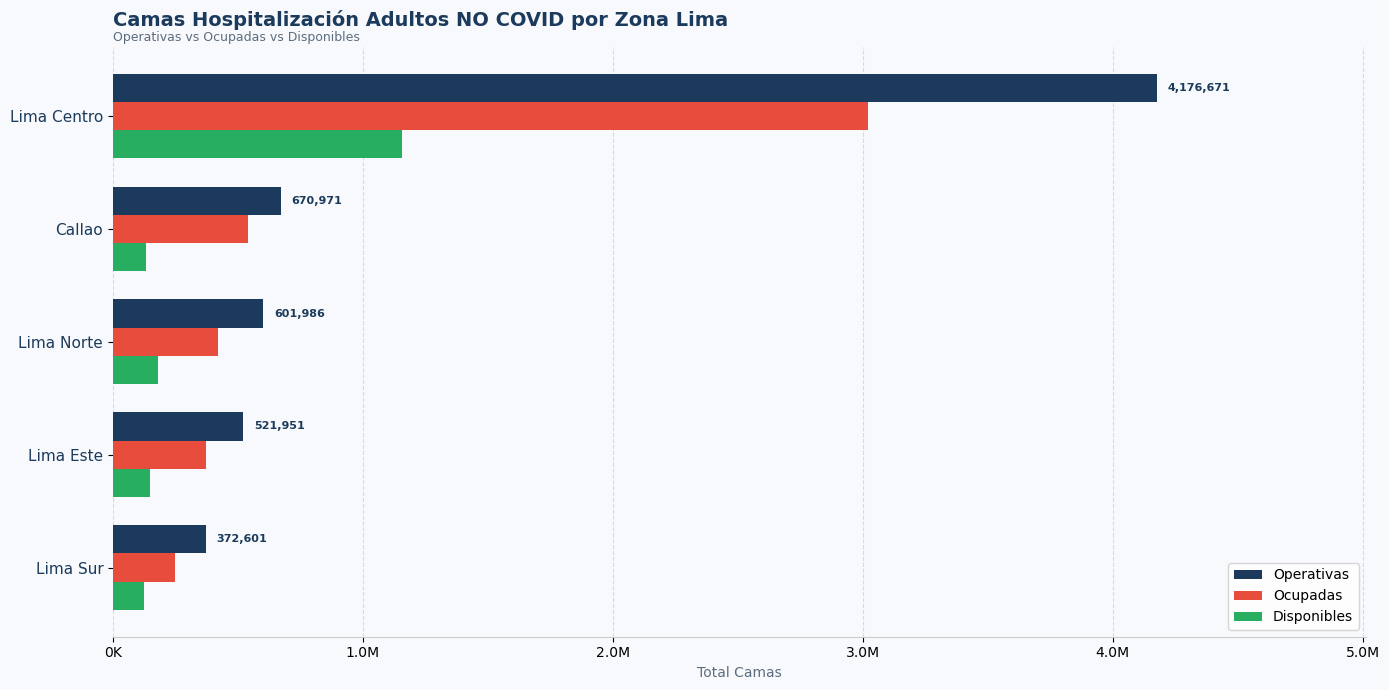

✅ Gráfico 1 guardado!


In [7]:
# ════════════════════════════════════════════════════════
# GRÁFICO 1 — Total camas por ZONA
# ════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np

resumen_zonas = resumen_zonas.sort_values("ZNC_HOSP_ADUL_CAM_OPERATIVO", ascending=True)
zonas  = resumen_zonas["ZONA_LIMA"].tolist()
x      = np.arange(len(zonas))
ancho  = 0.25

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("#F7F9FC")
ax.set_facecolor("#F7F9FC")

b1 = ax.barh(x + ancho, resumen_zonas["ZNC_HOSP_ADUL_CAM_OPERATIVO"],
             ancho, color="#1B3A5C", edgecolor="none", label="Operativas")
b2 = ax.barh(x,         resumen_zonas["ZNC_HOSP_ADUL_CAM_OCUPADO"],
             ancho, color="#E74C3C", edgecolor="none", label="Ocupadas")
b3 = ax.barh(x - ancho, resumen_zonas["ZNC_HOSP_ADUL_CAM_DISPONIBLE"],
             ancho, color="#27AE60", edgecolor="none", label="Disponibles")

for bar in b1:
    ax.text(bar.get_width() + resumen_zonas["ZNC_HOSP_ADUL_CAM_OPERATIVO"].max() * 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():,.0f}", va="center", fontsize=8,
            fontweight="bold", color="#1B3A5C")

ax.set_yticks(x)
ax.set_yticklabels(zonas, fontsize=11, color="#1B3A5C")
ax.set_title("Camas Hospitalización Adultos NO COVID por Zona Lima",
             fontsize=14, fontweight="bold", color="#1B3A5C", loc="left", pad=15)
ax.text(0, 1.01, "Operativas vs Ocupadas vs Disponibles",
        transform=ax.transAxes, fontsize=9, color="#5D6D7E")
ax.set_xlabel("Total Camas", fontsize=10, color="#5D6D7E")
ax.xaxis.grid(True, linestyle="--", alpha=0.4, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_xlim(0, resumen_zonas["ZNC_HOSP_ADUL_CAM_OPERATIVO"].max() * 1.2)
ax.xaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{int(x/1e3)}K"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")

from matplotlib.patches import Patch
leyenda = [Patch(facecolor="#1B3A5C", label="Operativas"),
           Patch(facecolor="#E74C3C", label="Ocupadas"),
           Patch(facecolor="#27AE60", label="Disponibles")]
ax.legend(handles=leyenda, loc="lower right", fontsize=10,
          framealpha=0.8, edgecolor="#CCCCCC")

plt.tight_layout()
plt.savefig("camas_zonas_total.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráfico 1 guardado!")

### GRÁFICO POR DISTRITOS DE LIMA

In [8]:
# ── Total por distrito ───────────────────────────────────
resumen_dist = data_camas_lima.groupby(["ZONA_LIMA","DISTRITO"])[cols].sum().reset_index()
resumen_dist["TASA_%"] = (
    resumen_dist["ZNC_HOSP_ADUL_CAM_OCUPADO"] /
    resumen_dist["ZNC_HOSP_ADUL_CAM_OPERATIVO"] * 100).round(1)

resumen_dist = resumen_dist[resumen_dist["ZNC_HOSP_ADUL_CAM_OPERATIVO"] > 0]

zonas = ["Lima Centro", "Lima Norte", "Lima Este", "Lima Sur", "Callao"]

for zona in zonas:
    df = resumen_dist[resumen_dist["ZONA_LIMA"] == zona].sort_values("TASA_%", ascending=False)
    print(f"\n{'=' * 70}")
    print(f"📍 {zona}")
    print(f"{'=' * 70}")
    print(f"{'DISTRITO':<28} {'OPERATIVAS':>10} {'OCUPADAS':>10} {'DISPONIBLES':>12} {'TASA%':>8}")
    print("-" * 70)
    for _, row in df.iterrows():
        emoji = "🔴" if row["TASA_%"] >= 80 else "🟡" if row["TASA_%"] >= 60 else "🟢"
        print(f"  {row['DISTRITO']:<26} "
              f"{row['ZNC_HOSP_ADUL_CAM_OPERATIVO']:>10,.0f} "
              f"{row['ZNC_HOSP_ADUL_CAM_OCUPADO']:>10,.0f} "
              f"{row['ZNC_HOSP_ADUL_CAM_DISPONIBLE']:>12,.0f} "
              f"{row['TASA_%']:>7.1f}% {emoji}")


📍 Lima Centro
DISTRITO                     OPERATIVAS   OCUPADAS  DISPONIBLES    TASA%
----------------------------------------------------------------------
  LA VICTORIA                   510,830    455,951       54,879    89.3% 🔴
  LIMA                          903,399    731,819      171,580    81.0% 🔴
  SAN ISIDRO                    193,233    149,185       44,048    77.2% 🟡
  SAN MIGUEL                    108,745     78,238       30,507    71.9% 🟡
  SANTIAGO DE SURCO             108,809     76,519       32,290    70.3% 🟡
  SURQUILLO                     202,475    141,388       61,087    69.8% 🟡
  SAN BORJA                     183,028    126,052       56,976    68.9% 🟡
  PUEBLO LIBRE                  133,732     91,843       41,894    68.7% 🟡
  LA MOLINA                      43,561     29,190       14,371    67.0% 🟡
  MAGDALENA DEL MAR             292,807    195,414       97,393    66.7% 🟡
  JESUS MARIA                 1,175,697    762,757      412,940    64.9% 🟡
  MIRAFLORES    

##### Ahora para un mejor análisis distrital nos etsamos enfocando en los top 8 para poder apreciar mejor las camas operativas,ocupadas y disponibles para los pacientes

C:\Users\PROPIETARIO\AppData\Local\Temp\ipykernel_35148\1579494731.py:52: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PROPIETARIO\AppData\Local\Temp\ipykernel_35148\1579494731.py:53: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) DejaVu Sans.
  plt.savefig("top8_por_zona_camas.png", dpi=200, bbox_inches="tight")
c:\Users\PROPIETARIO\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


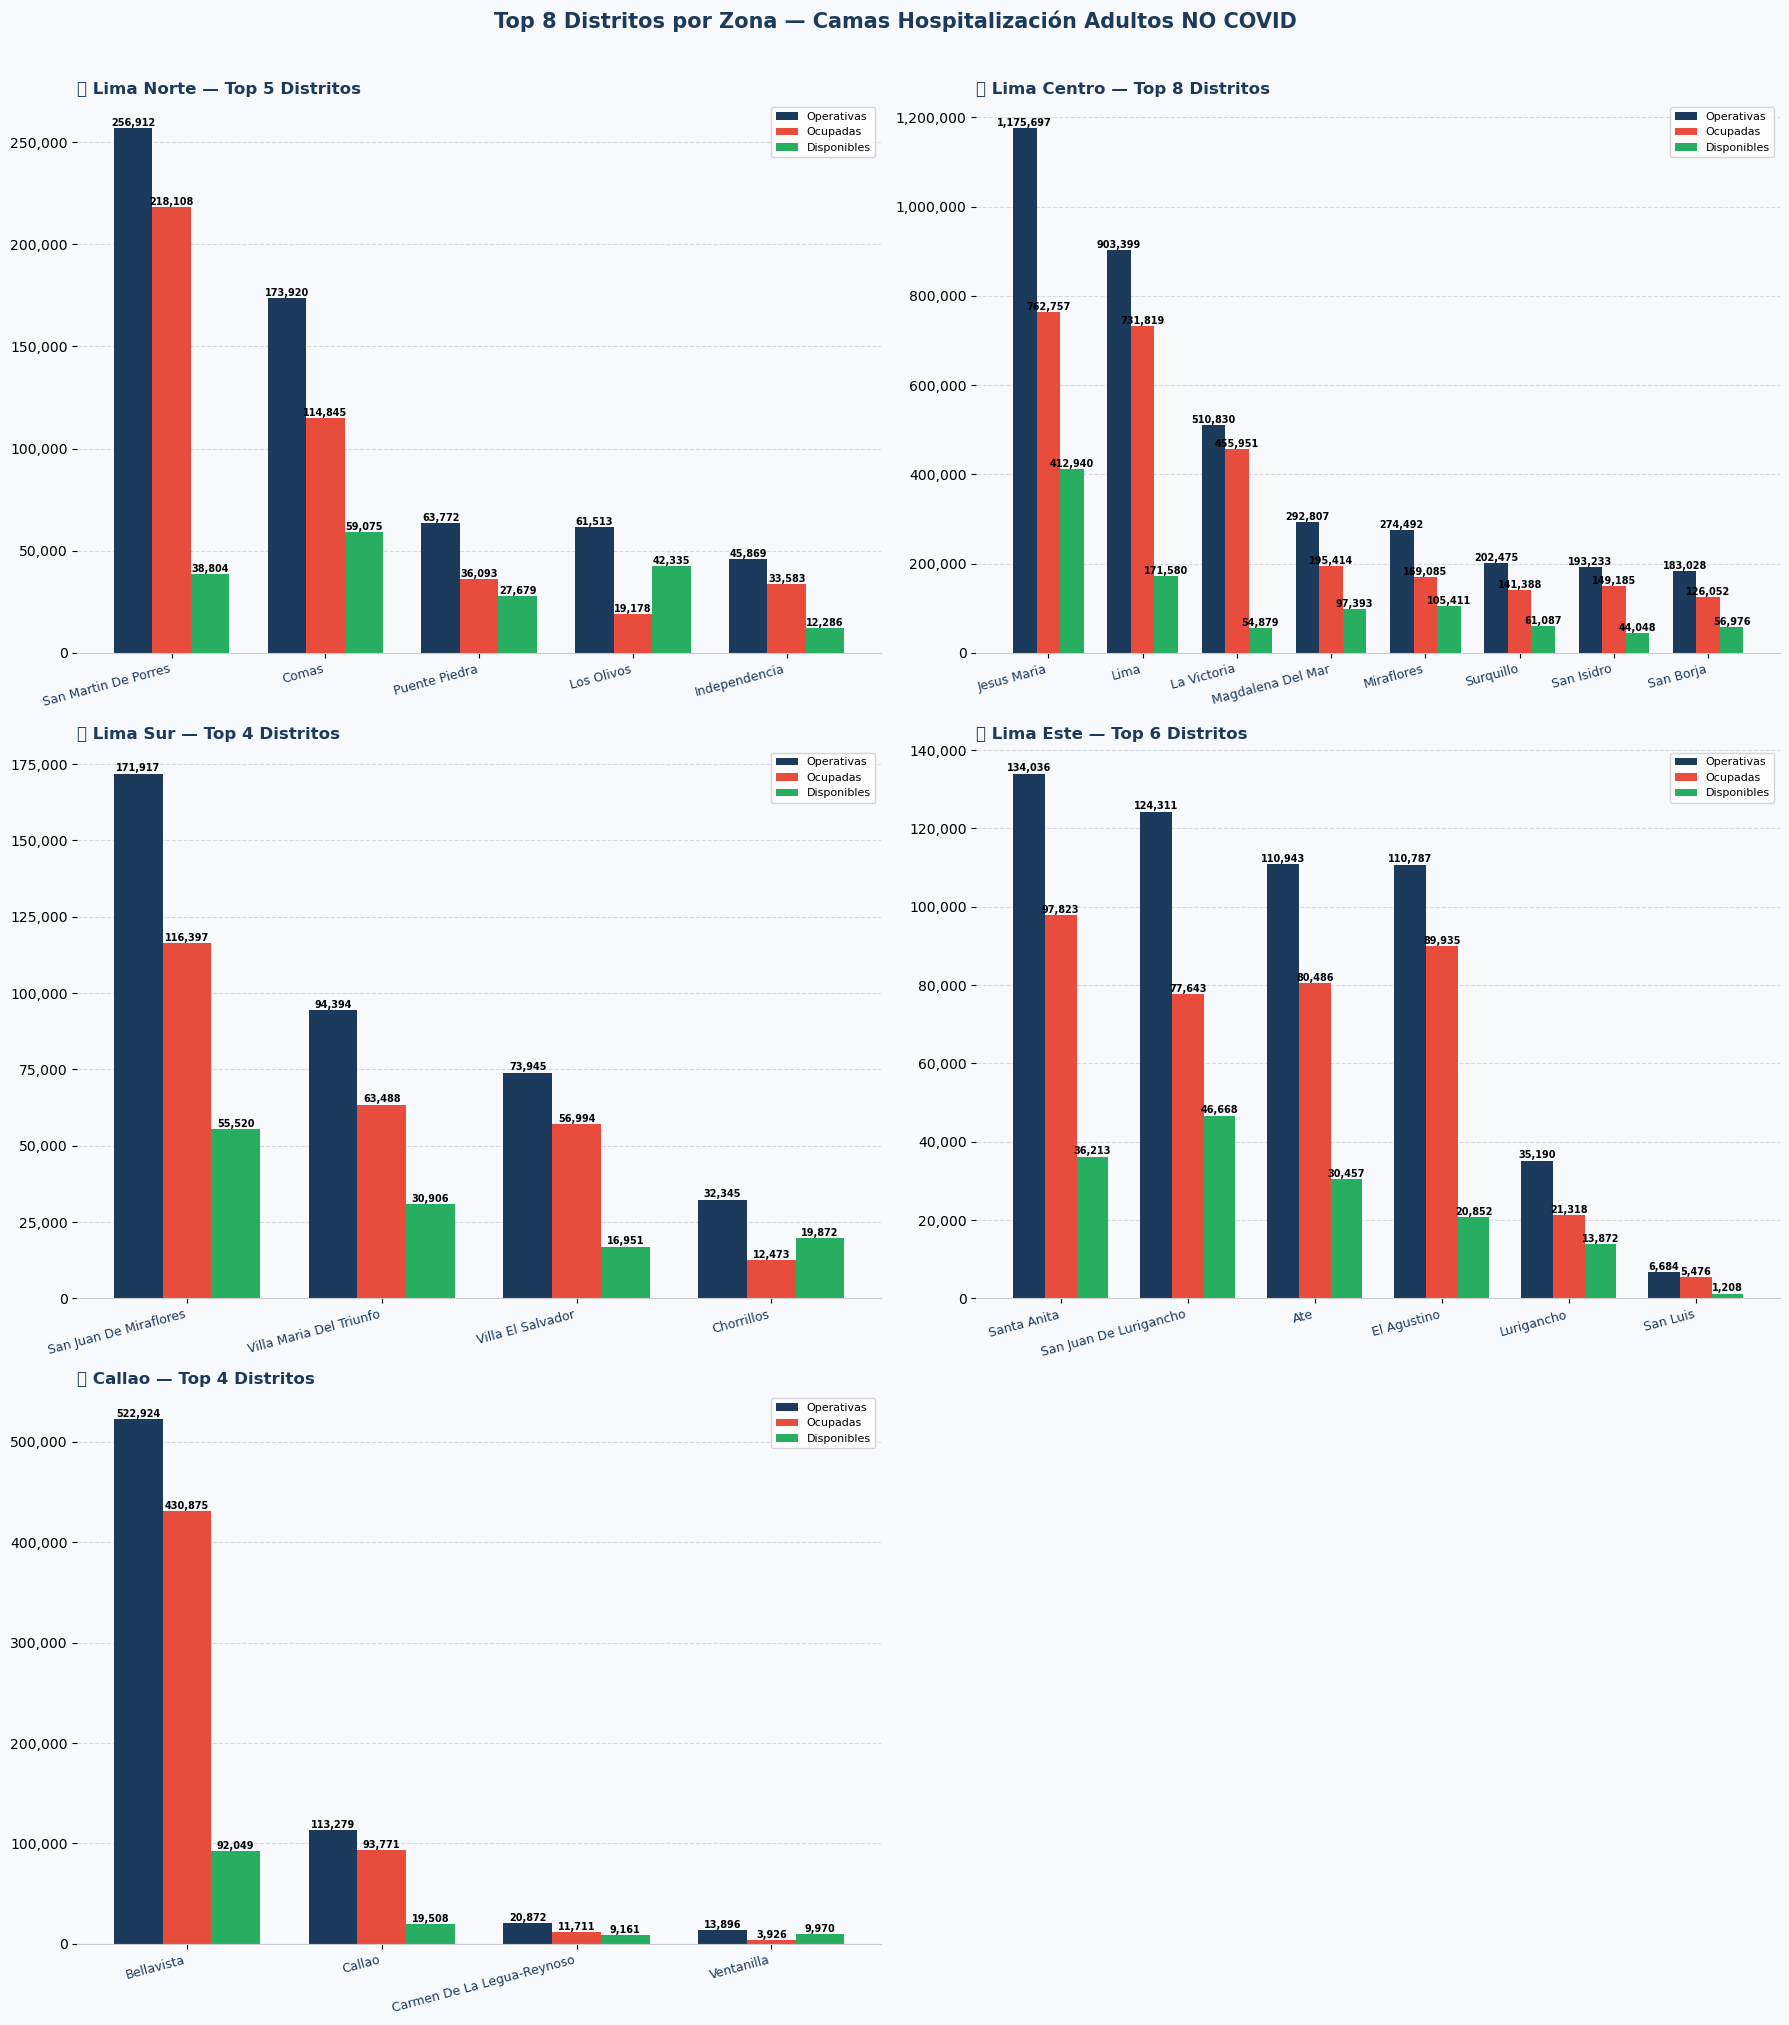

✅ Gráfico guardado!


In [9]:
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
fig.patch.set_facecolor("#F7F9FC")
axes = axes.flatten()

zonas = ["Lima Norte", "Lima Centro", "Lima Sur", "Lima Este", "Callao"]

for i, zona in enumerate(zonas):
    ax = axes[i]
    ax.set_facecolor("#F7F9FC")

    subset = data_camas_lima[data_camas_lima["ZONA_LIMA"] == zona]
    resumen = (subset.groupby("DISTRITO_REF")[cols].sum()
               .sort_values("ZNC_HOSP_ADUL_CAM_OPERATIVO", ascending=False)
               .head(8).reset_index())

    x     = np.arange(len(resumen))
    ancho = 0.25

    b1 = ax.bar(x - ancho, resumen["ZNC_HOSP_ADUL_CAM_OPERATIVO"],
                ancho, color="#1B3A5C", label="Operativas")
    b2 = ax.bar(x,         resumen["ZNC_HOSP_ADUL_CAM_OCUPADO"],
                ancho, color="#E74C3C", label="Ocupadas")
    b3 = ax.bar(x + ancho, resumen["ZNC_HOSP_ADUL_CAM_DISPONIBLE"],
                ancho, color="#27AE60", label="Disponibles")

    for bar in [*b1, *b2, *b3]:
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                    f"{int(bar.get_height()):,}",
                    ha="center", va="bottom", fontsize=7, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(resumen["DISTRITO_REF"], rotation=15,
                       ha="right", fontsize=9, color="#1B3A5C")
    ax.set_title(f"🏙️ {zona} — Top {len(resumen)} Distritos",
                 fontsize=12, fontweight="bold", color="#1B3A5C", loc="left")
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, color="#AAAAAA")
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#CCCCCC")
    ax.legend(fontsize=8, framealpha=0.8, edgecolor="#CCCCCC")

# ── Ocultar el subplot sobrante ───────────────────────────
axes[5].set_visible(False)

fig.suptitle("Top 8 Distritos por Zona — Camas Hospitalización Adultos NO COVID",
             fontsize=15, fontweight="bold", color="#1B3A5C", y=1.01)

plt.tight_layout()
plt.savefig("top8_por_zona_camas.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado!")

## Análisis de los 3 tipos de variables(camas/operativas,ocupadas,disponibles)

#####
 Camas operativas:
Son todas las camas que están habilitadas para usarse (tienen personal, equipos, funcionan).
👉 Es la capacidad total real del hospital.

Camas disponibles:
Son las camas operativas que están libres en ese momento.
👉 Es la capacidad que aún puedes usar ahora mismo.

Camas ocupadas (para completar):
Son las que ya tienen pacientes.

In [10]:
#-# ── Columnas usadas ──────────────────────────────────────

"ZNC_HOSP_ADUL_CAM_OPERATIVO"   # Camas operativas hospitalización adultos NO COVID
"ZNC_HOSP_ADUL_CAM_OCUPADO"     # Camas ocupadas hospitalización adultos NO COVID
"ZNC_HOSP_ADUL_CAM_DISPONIBLE"  # Camas disponibles hospitalización adultos NO COVID

'ZNC_HOSP_ADUL_CAM_DISPONIBLE'

##### construyendo un indicador clave de presión del sistema de salud por zona, que sirve para identificar dónde hay saturación y dónde aún hay capacidad. midiendo camas (ocupadas/camas operativas)*100 y con esto ver que tan saturada estan las camas hospitalarias

In [11]:
# ── Limpiar columnas necesarias ──────────────────────────
cols = ["ZNC_HOSP_ADUL_CAM_OPERATIVO", 
        "ZNC_HOSP_ADUL_CAM_DISPONIBLE",
        "ZNC_HOSP_ADUL_CAM_OCUPADO",
        "ZNC_HOSP_ADUL_CAM_TOTAL"]

for col in cols:
    data_camas_lima[col] = pd.to_numeric(data_camas_lima[col], errors="coerce")

# ── Tasa de ocupación por zona ───────────────────────────
resumen_zonas = data_camas_lima.groupby("ZONA_LIMA")[
    ["ZNC_HOSP_ADUL_CAM_OPERATIVO", 
     "ZNC_HOSP_ADUL_CAM_DISPONIBLE",
     "ZNC_HOSP_ADUL_CAM_OCUPADO"]].sum().reset_index()

resumen_zonas["TASA_OCUPACION"] = (
    resumen_zonas["ZNC_HOSP_ADUL_CAM_OCUPADO"] /
    resumen_zonas["ZNC_HOSP_ADUL_CAM_OPERATIVO"] * 100
).round(1)

print("=" * 55)
print("📊 TASA DE OCUPACIÓN DE CAMAS POR ZONA")
print("=" * 55)
for _, row in resumen_zonas.sort_values("TASA_OCUPACION", ascending=False).iterrows():
    emoji = "🔴" if row["TASA_OCUPACION"] >= 80 else "🟡" if row["TASA_OCUPACION"] >= 60 else "🟢"
    print(f"  {row['ZONA_LIMA']:<15} {row['TASA_OCUPACION']:>8.1f}%  {emoji}")

📊 TASA DE OCUPACIÓN DE CAMAS POR ZONA
  Callao              80.5%  🔴
  Lima Centro         72.3%  🟡
  Lima Este           71.4%  🟡
  Lima Norte          70.1%  🟡
  Lima Sur            66.9%  🟡


##### En Lima Metropolitana, la ocupación de camas hospitalarias se mantiene en niveles medios-altos en todas las zonas (66.9%–72.3%). No se identifican niveles críticos, pero tampoco zonas con capacidad óptima, lo que evidencia un sistema operando bajo presión sostenida y con limitada holgura ante aumentos en la demanda.

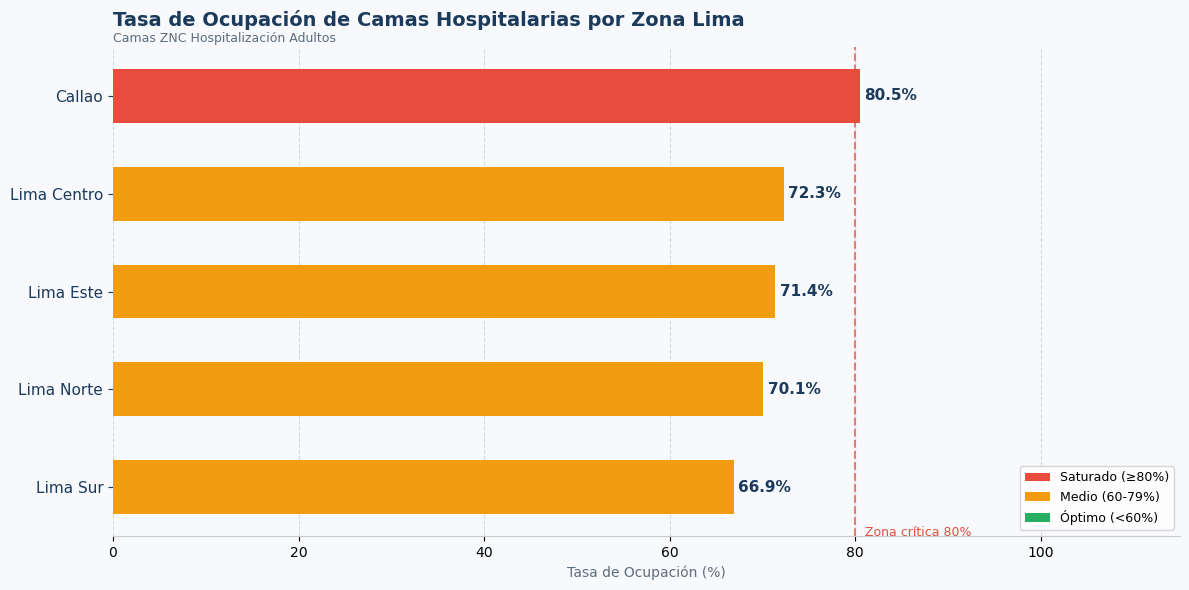

✅ Gráfico 1 guardado!


In [12]:
# ════════════════════════════════════════════════════════
# GRÁFICO 1 — Tasa de ocupación por ZONA
# ════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

resumen_zonas = resumen_zonas.sort_values("TASA_OCUPACION", ascending=True)

colores_tasa = []
for t in resumen_zonas["TASA_OCUPACION"]:
    if t >= 80:   colores_tasa.append("#E74C3C")   # Rojo = saturado
    elif t >= 60: colores_tasa.append("#F39C12")   # Naranja = medio
    else:         colores_tasa.append("#27AE60")   # Verde = ok

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#F7F9FC")
ax.set_facecolor("#F7F9FC")

bars = ax.barh(resumen_zonas["ZONA_LIMA"], resumen_zonas["TASA_OCUPACION"],
               color=colores_tasa, edgecolor="none", height=0.55)

# Línea de referencia 80%
ax.axvline(x=80, color="#E74C3C", linestyle="--", linewidth=1.5, alpha=0.7)
ax.text(81, -0.5, "Zona crítica 80%", color="#E74C3C", fontsize=9)

for bar, valor in zip(bars, resumen_zonas["TASA_OCUPACION"]):
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{valor:.1f}%", va="center", fontsize=11,
            fontweight="bold", color="#1B3A5C")

ax.set_title("Tasa de Ocupación de Camas Hospitalarias por Zona Lima",
             fontsize=14, fontweight="bold", color="#1B3A5C", loc="left", pad=15)
ax.text(0, 1.01, "Camas ZNC Hospitalización Adultos",
        transform=ax.transAxes, fontsize=9, color="#5D6D7E")
ax.set_xlabel("Tasa de Ocupación (%)", fontsize=10, color="#5D6D7E")
ax.set_xlim(0, 115)
ax.xaxis.grid(True, linestyle="--", alpha=0.4, color="#AAAAAA")
ax.set_axisbelow(True)
ax.tick_params(axis="y", labelsize=11, colors="#1B3A5C")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")

# Leyenda
from matplotlib.patches import Patch
leyenda = [Patch(facecolor="#E74C3C", label="Saturado (≥80%)"),
           Patch(facecolor="#F39C12", label="Medio (60-79%)"),
           Patch(facecolor="#27AE60", label="Óptimo (<60%)")]
ax.legend(handles=leyenda, loc="lower right", fontsize=9,
          framealpha=0.8, edgecolor="#CCCCCC")

plt.tight_layout()
plt.savefig("tasa_ocupacion_zonas.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráfico 1 guardado!")

##### El gráfico muestra que varios distritos presentan **alta ocupación de camas (>80%)**, como La Victoria (89.3%), San Martín de Porres (84.9%) y Callao (82.8%), lo que indica **saturación**. Otros se ubican en un nivel medio, como Ate (72.5%) y Comas (66.0%), mientras que algunos distritos periféricos tienen menor presión, como Ventanilla (28.3%) y Chorrillos (38.6%). En general, la mayor saturación se concentra en zonas centrales y urbanas.


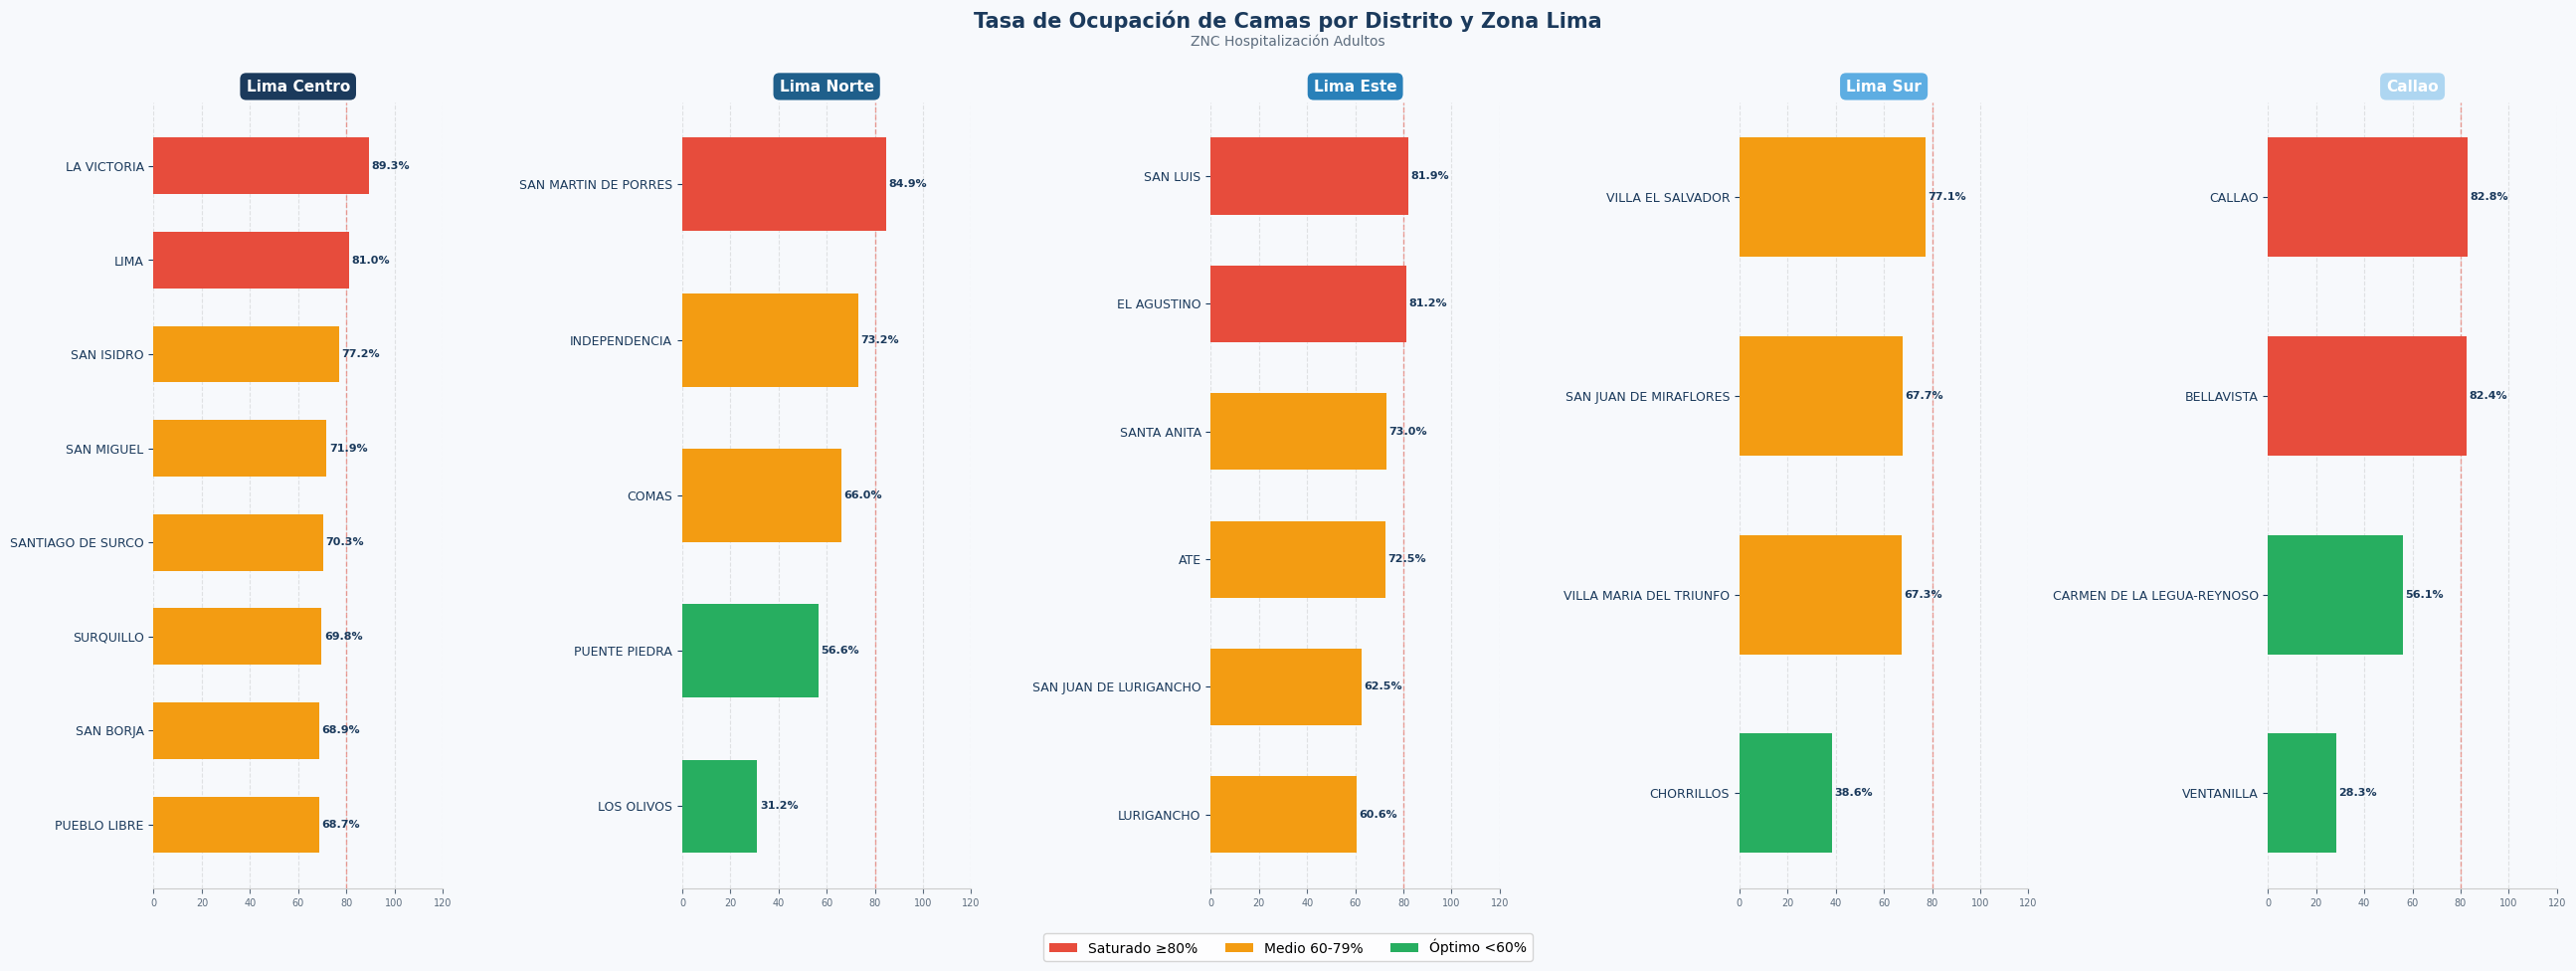

✅ Gráfico 2 guardado!


In [13]:
# ════════════════════════════════════════════════════════
# GRÁFICO 2 — Tasa de ocupación por DISTRITO (Top 8 x zona)
# ════════════════════════════════════════════════════════
resumen_dist = data_camas_lima.groupby(["ZONA_LIMA", "DISTRITO"])[
    ["ZNC_HOSP_ADUL_CAM_OPERATIVO",
     "ZNC_HOSP_ADUL_CAM_OCUPADO"]].sum().reset_index()

resumen_dist["TASA_OCUPACION"] = (
    resumen_dist["ZNC_HOSP_ADUL_CAM_OCUPADO"] /
    resumen_dist["ZNC_HOSP_ADUL_CAM_OPERATIVO"] * 100
).round(1)

resumen_dist = resumen_dist[resumen_dist["ZNC_HOSP_ADUL_CAM_OPERATIVO"] > 0]

top_dist = (resumen_dist.sort_values("TASA_OCUPACION", ascending=False)
            .groupby("ZONA_LIMA").head(8)
            .sort_values(["ZONA_LIMA", "TASA_OCUPACION"], ascending=[True, True]))

zonas = ["Lima Centro", "Lima Norte", "Lima Este", "Lima Sur", "Callao"]

fig, axes = plt.subplots(1, 5, figsize=(26, 9))
fig.patch.set_facecolor("#F7F9FC")
fig.suptitle("Tasa de Ocupación de Camas por Distrito y Zona Lima",
             fontsize=15, fontweight="bold", color="#1B3A5C", y=1.02)
fig.text(0.5, 0.98, "ZNC Hospitalización Adultos",
         ha="center", fontsize=10, color="#5D6D7E")

colores_zona = {
    "Lima Centro": "#1B3A5C",
    "Lima Norte":  "#1F5F8B",
    "Lima Este":   "#2980B9",
    "Lima Sur":    "#5DADE2",
    "Callao":      "#AED6F1"
}

for ax, zona in zip(axes, zonas):
    df = top_dist[top_dist["ZONA_LIMA"] == zona].copy()
    color = colores_zona[zona]

    colores_barras = []
    for t in df["TASA_OCUPACION"]:
        if t >= 80:   colores_barras.append("#E74C3C")
        elif t >= 60: colores_barras.append("#F39C12")
        else:         colores_barras.append("#27AE60")

    ax.set_facecolor("#F7F9FC")
    bars = ax.barh(df["DISTRITO"], df["TASA_OCUPACION"],
                   color=colores_barras, edgecolor="none", height=0.6)

    ax.axvline(x=80, color="#E74C3C", linestyle="--", linewidth=1, alpha=0.5)

    for bar, valor in zip(bars, df["TASA_OCUPACION"]):
        ax.text(bar.get_width() + 1,
                bar.get_y() + bar.get_height() / 2,
                f"{valor:.1f}%", va="center", fontsize=8,
                fontweight="bold", color="#1B3A5C")

    ax.set_title(zona, fontsize=11, fontweight="bold", color="white", pad=8,
                 bbox=dict(boxstyle="round,pad=0.4", facecolor=color, edgecolor="none"))
    ax.xaxis.grid(True, linestyle="--", alpha=0.3, color="#AAAAAA")
    ax.set_axisbelow(True)
    ax.set_xlim(0, 120)
    ax.tick_params(axis="y", labelsize=9, colors="#1B3A5C")
    ax.tick_params(axis="x", labelsize=7, colors="#5D6D7E")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#CCCCCC")

from matplotlib.patches import Patch
leyenda = [Patch(facecolor="#E74C3C", label="Saturado ≥80%"),
           Patch(facecolor="#F39C12", label="Medio 60-79%"),
           Patch(facecolor="#27AE60", label="Óptimo <60%")]
fig.legend(handles=leyenda, loc="lower center", ncol=3,
           fontsize=10, framealpha=0.8, edgecolor="#CCCCCC",
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig("tasa_ocupacion_distritos.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráfico 2 guardado!")

In [14]:
# ── Distritos por zona en data camas ────────────────────
zonas = ["Lima Centro", "Lima Norte", "Lima Este", "Lima Sur", "Callao"]

for zona in zonas:
    df = (data_camas_lima[data_camas_lima["ZONA_LIMA"] == zona]
          .groupby("DISTRITO").size()
          .reset_index(name="Registros")
          .sort_values("Registros", ascending=False))
    
    print(f"\n📍 {zona} — {len(df)} distritos")
    print("=" * 45)
    for _, row in df.iterrows():
        print(f"  ✅ {row['DISTRITO']:<30} {row['Registros']:>6,} registros")
    print(f"  {'TOTAL':<30} {df['Registros'].sum():>6,}")


📍 Lima Centro — 15 distritos
  ✅ LIMA                            9,288 registros
  ✅ SAN BORJA                       8,479 registros
  ✅ MIRAFLORES                      8,148 registros
  ✅ JESUS MARIA                     6,984 registros
  ✅ SAN ISIDRO                      6,657 registros
  ✅ SANTIAGO DE SURCO               4,656 registros
  ✅ PUEBLO LIBRE                    3,489 registros
  ✅ SAN MIGUEL                      3,415 registros
  ✅ MAGDALENA DEL MAR               2,897 registros
  ✅ SURQUILLO                       2,894 registros
  ✅ LINCE                           2,313 registros
  ✅ LA VICTORIA                     1,746 registros
  ✅ LA MOLINA                       1,697 registros
  ✅ BREÑA                           1,164 registros
  ✅ RIMAC                             266 registros
  TOTAL                          64,093

📍 Lima Norte — 5 distritos
  ✅ LOS OLIVOS                      5,188 registros
  ✅ COMAS                           4,264 registros
  ✅ SAN MARTIN DE 

## Emergencia

In [72]:

## INFO COMPLETA
import pandas as pd
import os

ruta_base = r"C:\Users\PROPIETARIO\Desktop\PROGRAMACIÓN\PRACTICANDO-PYTHON\PROYECTO CLINICA\emergencia"

archivos = [f for f in os.listdir(ruta_base) 
            if f.endswith(".xlsx") or f.endswith(".csv")]

dataframes = []
for archivo in archivos:
    ruta = os.path.join(ruta_base, archivo)
    try:
        df = pd.read_csv(ruta, sep="|", encoding="utf-8-sig")
    except:
        try:
            df = pd.read_csv(ruta, encoding="latin-1", sep=";")
        except:
            df = pd.read_excel(ruta)
    print(f"✅ {archivo} — {len(df)} filas")
    dataframes.append(df)

data_emergencia = pd.concat(dataframes, ignore_index=True)
print(f"\n📊 Total: {len(data_emergencia)} filas")
print(f"📋 Columnas: {data_emergencia.columns.tolist()}")

✅ ConsultaC2_2024_III_v7.csv — 1644361 filas
✅ ConsultaC2_2024_II_v10.csv — 1590811 filas
✅ ConsultaC2_2024_I_v4.csv — 1575485 filas
✅ ConsultaC2_2025_III_v5.csv — 1851350 filas
✅ ConsultaC2_2025_II_v8.csv — 1787215 filas
✅ ConsultaC2_2025_I_v8.csv — 1715341 filas

📊 Total: 10164563 filas
📋 Columnas: ['ANHO', 'MES', 'UBIGEO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'SECTOR', 'CATEGORIA', 'CO_IPRESS', 'RAZON_SOC', 'SEXO', 'EDAD', 'ID_DIGNOSTICO', 'DIGNOSTICO', 'NU_TOTAL_ATENDIDOS']


### Clasificacíon por distrito

##### En términos de distribución, la mayor carga se concentra en Lima Centro con 2,044,475 atenciones (aprox. 47%), lo que evidencia una fuerte centralización de la demanda. Le siguen Lima Norte (630 mil), Lima Este (586 mil) y Callao (564 mil) con niveles intermedios, mientras que Lima Sur presenta la menor participación con 510 mil atenciones.

In [73]:
# ── PASO 1: Filtrar Lima y Callao ─────────────────────────
data_emergencia_lima_region = data_emergencia[
    data_emergencia["PROVINCIA"].isin(["LIMA", "CALLAO"])
].copy()

print(f"✅ Lima + Callao: {len(data_emergencia_lima_region):,} filas")

# ── PASO 2: Clasificar por Zonas ─────────────────────────
data_emergencia_lima_region["ZONA_LIMA"] = (
    data_emergencia_lima_region["DISTRITO"].str.strip().str.title().map(asignar_zona)
)

data_emergencia_lima = data_emergencia_lima_region[
    data_emergencia_lima_region["ZONA_LIMA"] != "Fuera de Lima"
].copy()

print(f"✅ Total clasificado: {len(data_emergencia_lima):,} filas")
print(f"\n📊 Distribución por zona:")
print(data_emergencia_lima["ZONA_LIMA"].value_counts())

# ── Sin clasificar ────────────────────────────────────────
fuera = data_emergencia_lima_region[
    data_emergencia_lima_region["ZONA_LIMA"] == "Fuera de Lima"
]
print(f"\n⚠️ Sin clasificar: {len(fuera):,} filas")
print(fuera["DISTRITO"].str.strip().str.title().value_counts().head(20).to_string())

✅ Lima + Callao: 4,335,716 filas
✅ Total clasificado: 4,335,716 filas

📊 Distribución por zona:
ZONA_LIMA
Lima Centro    2044475
Lima Norte      630344
Lima Este       586271
Callao          564242
Lima Sur        510384
Name: count, dtype: int64

⚠️ Sin clasificar: 0 filas
Series([], )


##### Se clasificaron más de 4.3 millones de atenciones en Lima y Callao sin registros perdidos. La mayor concentración está en Lima Centro (47.2%), seguida por Lima Norte (14.5%), evidenciando una alta centralización de la demanda en distritos como Lima, Miraflores y San Isidro.

In [74]:
print("📊 DISTRITOS CLASIFICADOS POR ZONA:\n")
total = len(data_emergencia_lima)

for zona in ["Lima Norte", "Lima Centro", "Lima Sur", "Lima Este", "Callao"]:
    subset = data_emergencia_lima[data_emergencia_lima["ZONA_LIMA"] == zona]
    distritos = sorted(subset["DISTRITO"].str.strip().str.title().dropna().unique())
    pct = len(subset) / total * 100
    print(f"🏙️ {zona} — {len(subset):,} filas ({pct:.1f}%) — {len(distritos)} distritos:")
    for d in distritos:
        cnt = subset[subset["DISTRITO"].str.strip().str.title() == d].shape[0]
        print(f"   - {d:<35} {cnt:>8,} filas")
    print()

# ── Sin clasificar ────────────────────────────────────────
fuera = data_emergencia_lima_region[data_emergencia_lima_region["ZONA_LIMA"] == "Fuera de Lima"]
print(f"❌ Sin clasificar — {len(fuera):,} filas")
if len(fuera) > 0:
    for d in sorted(fuera["DISTRITO"].str.strip().str.title().dropna().unique()):
        cnt = fuera[fuera["DISTRITO"].str.strip().str.title() == d].shape[0]
        prov = fuera[fuera["DISTRITO"].str.strip().str.title() == d]["PROVINCIA"].iloc[0]
        print(f"   ❌ {d:<35} {prov:<15} {cnt:>8,} filas")
else:
    print("   ✅ Todos los distritos fueron clasificados correctamente")

📊 DISTRITOS CLASIFICADOS POR ZONA:

🏙️ Lima Norte — 630,344 filas (14.5%) — 7 distritos:
   - Ancon                                  8,189 filas
   - Carabayllo                             6,382 filas
   - Comas                                141,977 filas
   - Independencia                         96,290 filas
   - Los Olivos                           135,645 filas
   - Puente Piedra                         66,217 filas
   - San Martin De Porres                 175,644 filas

🏙️ Lima Centro — 2,044,475 filas (47.2%) — 16 distritos:
   - Barranco                                  16 filas
   - Breña                                 31,171 filas
   - Jesus Maria                          271,523 filas
   - La Molina                            101,162 filas
   - La Victoria                          130,926 filas
   - Lima                                 339,672 filas
   - Lince                                  7,951 filas
   - Magdalena Del Mar                      7,177 filas
   - Miraflor

##### Aca verificamos los distritos no considerados para no sesgar ninguna información

In [75]:
fuera_de_lima_callao = data_emergencia[
    ~data_emergencia["PROVINCIA"].isin(["LIMA", "CALLAO"])
]

print(f"📊 Total fuera de Lima y Callao: {len(fuera_de_lima_callao):,} filas\n")
print(f"{'DEPARTAMENTO':<20} {'PROVINCIA':<25} {'FILAS':>10}")
print("-" * 60)
for (depto, prov), cnt in (fuera_de_lima_callao
                            .groupby(["DEPARTAMENTO", "PROVINCIA"])
                            .size()
                            .sort_values(ascending=False)
                            .items()):
    print(f"{depto:<20} {prov:<25} {cnt:>10,}")

📊 Total fuera de Lima y Callao: 5,828,847 filas

DEPARTAMENTO         PROVINCIA                      FILAS
------------------------------------------------------------
AREQUIPA             AREQUIPA                     444,408
LA LIBERTAD          TRUJILLO                     388,219
CUSCO                CUSCO                        266,690
ANCASH               SANTA                        212,294
ICA                  ICA                          186,729
LAMBAYEQUE           CHICLAYO                     183,348
LORETO               MAYNAS                       168,697
JUNIN                HUANCAYO                     167,002
PIURA                PIURA                        156,800
SAN MARTIN           SAN MARTIN                   139,447
LIMA                 HUAURA                       124,774
LIMA                 HUARAL                       108,312
PUNO                 PUNO                         103,743
ICA                  CHINCHA                      102,552
CAJAMARCA           

##### Aca se cuentan los Numeros totales atendidos

In [76]:
# ── Limpiar columna ──────────────────────────────────────
data_emergencia_lima["NU_TOTAL_ATENDIDOS"] = pd.to_numeric(
    data_emergencia_lima["NU_TOTAL_ATENDIDOS"], errors="coerce")

# ── Resumen por zona ─────────────────────────────────────
resumen_emer = (data_emergencia_lima.groupby("ZONA_LIMA")["NU_TOTAL_ATENDIDOS"]
                .sum().reset_index(name="Total")
                .sort_values("Total", ascending=False))

resumen_emer["%"] = (resumen_emer["Total"] / resumen_emer["Total"].sum() * 100).round(1)

print("=" * 55)
print("📊 EMERGENCIA — NU_TOTAL_ATENDIDOS POR ZONA")
print("=" * 55)
for _, row in resumen_emer.iterrows():
    print(f"  {row['ZONA_LIMA']:<15} {row['Total']:>15,.0f}  ({row['%']}%)")
print("-" * 55)
print(f"  {'TOTAL':<15} {resumen_emer['Total'].sum():>15,.0f}  (100%)")

📊 EMERGENCIA — NU_TOTAL_ATENDIDOS POR ZONA
  Lima Centro           4,835,329  (44.8%)
  Lima Este             1,682,579  (15.6%)
  Callao                1,496,453  (13.9%)
  Lima Norte            1,452,826  (13.5%)
  Lima Sur              1,315,106  (12.2%)
-------------------------------------------------------
  TOTAL                10,782,293  (100%)


### Graficación por Distrito

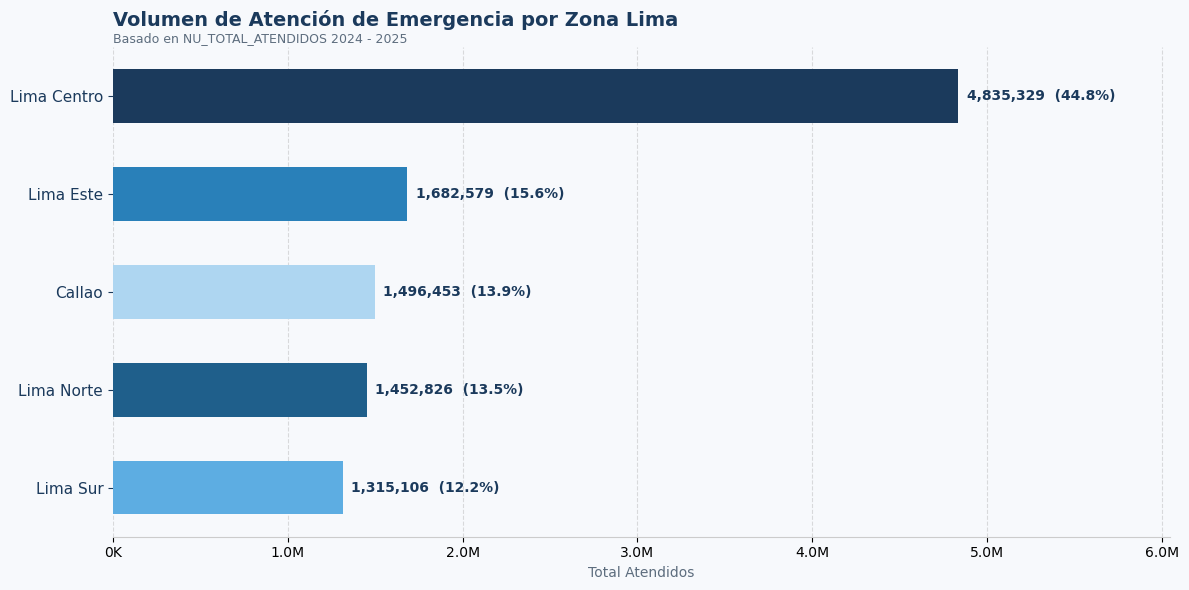

✅ Gráfico 1 guardado!


In [77]:
# ════════════════════════════════════════════════════════
# GRÁFICO 1 — Emergencia por zona
# ════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

colores_zona = {
    "Lima Centro": "#1B3A5C",
    "Lima Norte":  "#1F5F8B",
    "Lima Este":   "#2980B9",
    "Lima Sur":    "#5DADE2",
    "Callao":      "#AED6F1"
}

resumen_emer_g = resumen_emer.sort_values("Total", ascending=True)
colores = [colores_zona.get(z, "#999999") for z in resumen_emer_g["ZONA_LIMA"]]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#F7F9FC")
ax.set_facecolor("#F7F9FC")

bars = ax.barh(resumen_emer_g["ZONA_LIMA"], resumen_emer_g["Total"],
               color=colores, edgecolor="none", height=0.55)

for bar, valor, zona in zip(bars, resumen_emer_g["Total"], resumen_emer_g["ZONA_LIMA"]):
    pct = resumen_emer_g[resumen_emer_g["ZONA_LIMA"] == zona]["%"].values[0]
    ax.text(bar.get_width() + resumen_emer_g["Total"].max() * 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{valor:,.0f}  ({pct}%)", va="center", fontsize=10,
            fontweight="bold", color="#1B3A5C")

ax.set_title("Volumen de Atención de Emergencia por Zona Lima",
             fontsize=14, fontweight="bold", color="#1B3A5C", loc="left", pad=15)
ax.text(0, 1.01, "Basado en NU_TOTAL_ATENDIDOS 2024 - 2025",
        transform=ax.transAxes, fontsize=9, color="#5D6D7E")
ax.set_xlabel("Total Atendidos", fontsize=10, color="#5D6D7E")
ax.xaxis.grid(True, linestyle="--", alpha=0.4, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_xlim(0, resumen_emer_g["Total"].max() * 1.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{int(x/1e3)}K"))
ax.tick_params(axis="y", labelsize=11, colors="#1B3A5C")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")

plt.tight_layout()
plt.savefig("emergencia_zonas.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráfico 1 guardado!")

##### Aqui se visualiza top 8 para un mejor análisis

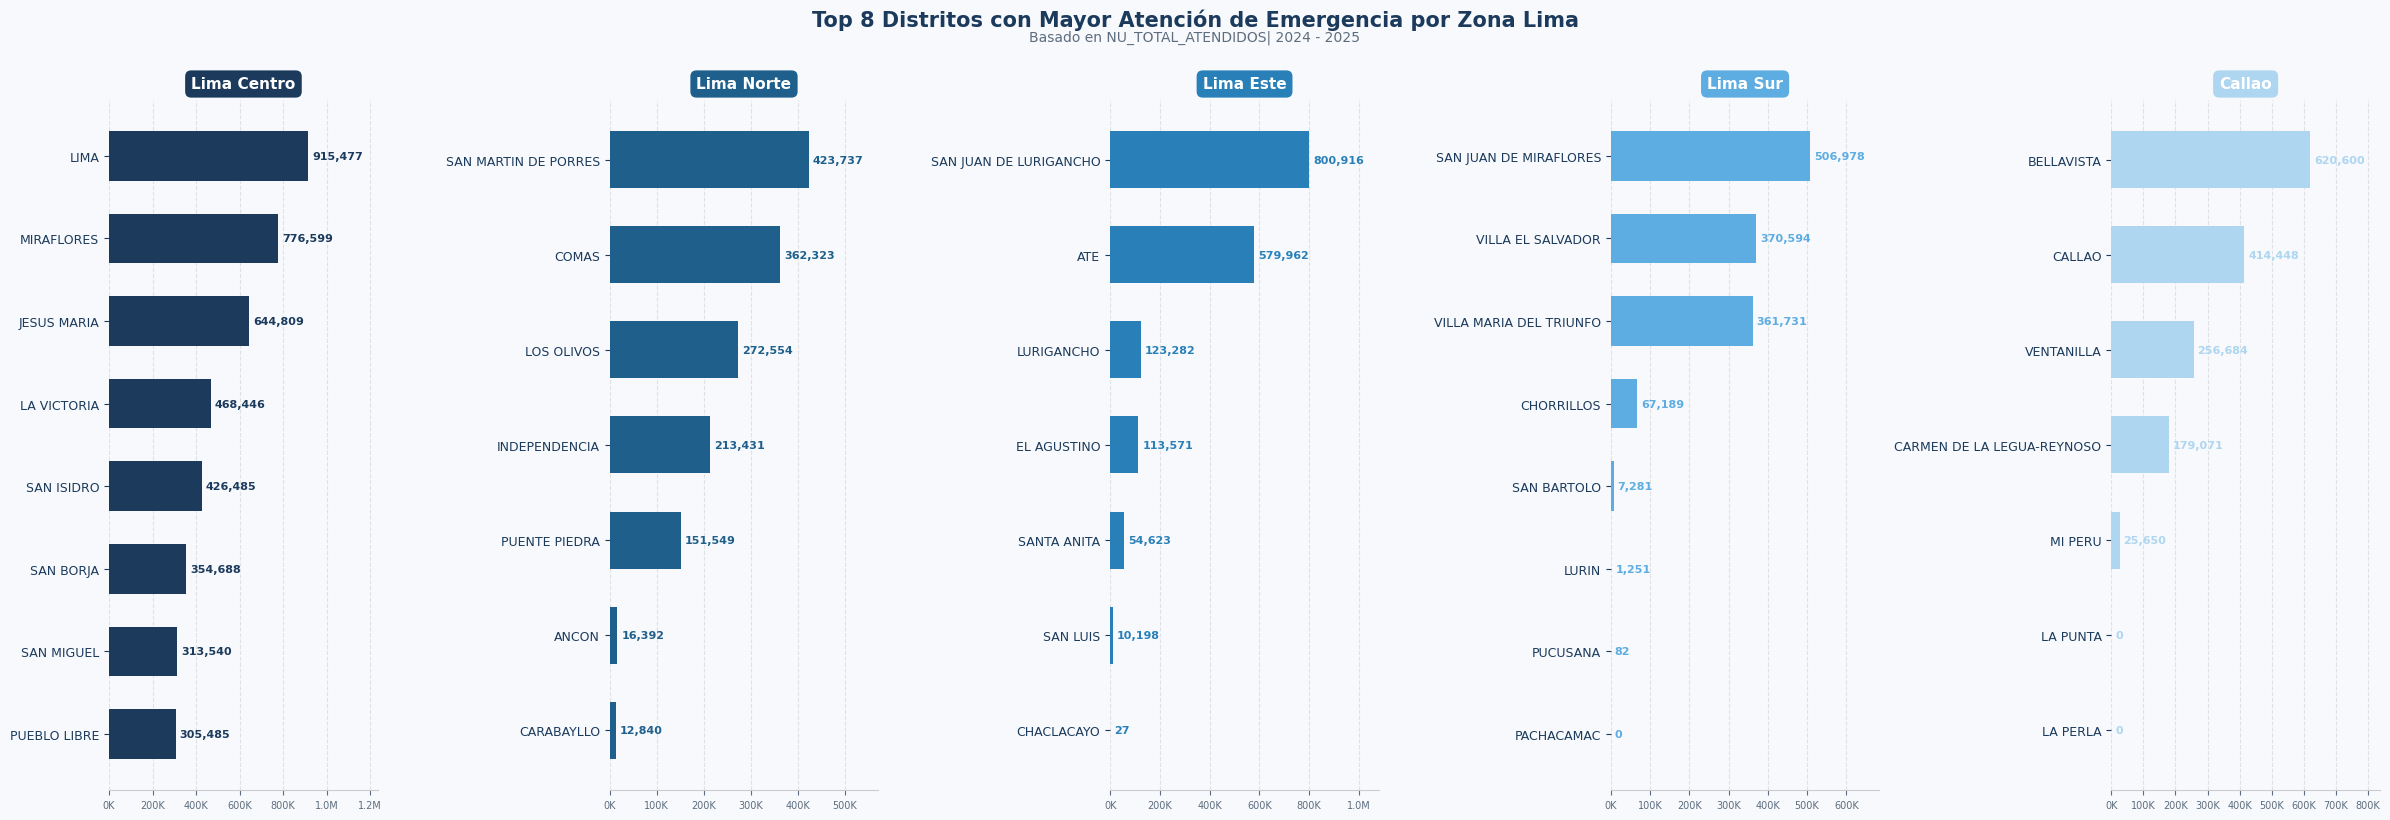

✅ Gráfico 2 guardado!


In [78]:
# ════════════════════════════════════════════════════════
# GRÁFICO 2 — Emergencia Top 8 distritos por zona
# ════════════════════════════════════════════════════════
top_emer = (data_emergencia_lima.groupby(["ZONA_LIMA","DISTRITO"])["NU_TOTAL_ATENDIDOS"]
            .sum().reset_index(name="Total")
            .sort_values("Total", ascending=False)
            .groupby("ZONA_LIMA").head(8)
            .sort_values(["ZONA_LIMA","Total"], ascending=[True, True]))

zonas = ["Lima Centro", "Lima Norte", "Lima Este", "Lima Sur", "Callao"]

fig, axes = plt.subplots(1, 5, figsize=(24, 8))
fig.patch.set_facecolor("#F7F9FC")
fig.suptitle("Top 8 Distritos con Mayor Atención de Emergencia por Zona Lima",
             fontsize=15, fontweight="bold", color="#1B3A5C", y=1.02)
fig.text(0.5, 0.98, "Basado en NU_TOTAL_ATENDIDOS| 2024 - 2025",
         ha="center", fontsize=10, color="#5D6D7E")

for ax, zona in zip(axes, zonas):
    df    = top_emer[top_emer["ZONA_LIMA"] == zona].copy()
    color = colores_zona[zona]

    ax.set_facecolor("#F7F9FC")
    bars = ax.barh(df["DISTRITO"], df["Total"],
                   color=color, edgecolor="none", height=0.6)

    for bar, valor in zip(bars, df["Total"]):
        ax.text(bar.get_width() + df["Total"].max() * 0.02,
                bar.get_y() + bar.get_height()/2,
                f"{valor:,.0f}", va="center", fontsize=8,
                fontweight="bold", color=color)

    ax.set_title(zona, fontsize=11, fontweight="bold", color="white", pad=8,
                 bbox=dict(boxstyle="round,pad=0.4", facecolor=color, edgecolor="none"))
    ax.xaxis.grid(True, linestyle="--", alpha=0.3, color="#AAAAAA")
    ax.set_axisbelow(True)
    ax.set_xlim(0, df["Total"].max() * 1.35)
    ax.tick_params(axis="y", labelsize=9, colors="#1B3A5C")
    ax.tick_params(axis="x", labelsize=7, colors="#5D6D7E")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(
        lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{int(x/1e3)}K"))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_color("#CCCCCC")

plt.tight_layout()
plt.savefig("emergencia_distritos.png", dpi=200, bbox_inches="tight")
plt.show()
print("✅ Gráfico 2 guardado!")